In [1]:
pip install kagglehub

Note: you may need to restart the kernel to use updated packages.


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import kagglehub

## Pregunta Inicial
- **Hipótesis en Bruto**:
	- Quien tiene mayor porcentaje de victorias Strikers o Grapplers?
	- Quien tiene peleas mas largas Strikers o Grapplers?
	- Cual es el porcentaje de victorias por tipo de peleador? (Strikers Vs Grapplers)
	- Que marca la diferencia en los encuentros?
	- Con que atributos esta relacionada la apuesta del peleador?
- **Hipótesis Finales (Base)**:
	- Existe una relación ente las apuestas (Favorito Vs UnderDog) con la victoria?
	- De qué manera esta relacionado el arquetipo del peleador con el resultado de la pelea? (Tiempo, Manera de Finalización)
	- Existe un patrón que explique el fenómeno de "La Invasión Daguestani"?

### Descargando Dataset 

In [3]:
path = kagglehub.dataset_download("mdabbert/ultimate-ufc-dataset")

print("Path to dataset files:", path)

Path to dataset files: /home/scoria/.cache/kagglehub/datasets/mdabbert/ultimate-ufc-dataset/versions/181


## Funciones

In [4]:
def generar_perfil_completo(nombre, df_ufc):
    mask = (df_ufc['R_fighter'] == nombre) | (df_ufc['B_fighter'] == nombre)
    participaciones = df_ufc[mask].copy()
    
    if participaciones.empty:
        return pd.Series([[], 0, 0, 0, 0, 0, 0, 0])

    indices_peleas = participaciones.index.tolist()
    total_fights = len(participaciones)
    
    wins, losses, draws = 0, 0, 0
    resultados_historicos = []

    for _, row in participaciones.iterrows():
        winner = row['Winner']
        if winner == 'Draw':
            res = 'D'; draws += 1
        elif (winner == 'Red' and row['R_fighter'] == nombre) or \
             (winner == 'Blue' and row['B_fighter'] == nombre):
            res = 'W'; wins += 1
        else:
            res = 'L'; losses += 1
        resultados_historicos.append(res)
    
    historial_rev = resultados_historicos[::-1]
    racha_w, racha_l, racha_d = 0, 0, 0
    
    if historial_rev:
        ultimo_res = historial_rev[0]
        for res in historial_rev:
            if res == ultimo_res:
                if res == 'W': racha_w += 1
                elif res == 'L': racha_l += 1
                elif res == 'D': racha_d += 1
            else:
                break
                
    return pd.Series([
        indices_peleas, total_fights, wins, losses, draws, 
        racha_w, racha_l, racha_d
    ])

In [5]:
def clasificar_arquetipo_base(row):
    td = row['avg_TD_landed']
    sub = row['avg_SUB_ATT']
    sig = row['avg_SIG_STR_landed']

    # Perfeccionar clasificacion
    es_grappler = (td > 1.5) or (sub > 0.7)
    es_striker  = (sig > 15) and (td < 1.0)
    
    if es_grappler and not es_striker:
        return 'Grappler'
    elif es_striker and not es_grappler:
        return 'Striker'
    else:
        return 'Completo'

### Importando Bibliotecas

In [6]:
import pandas as pd

### Cargando el DataFrame

In [7]:
df_ufc = pd.read_csv(f"{path}/ufc-master.csv")

*Primera Vista*

In [8]:
df_ufc.head()

,R_fighter,B_fighter,R_odds,B_odds,R_ev,B_ev,date,location,country,Winner,...,finish_details,finish_round,finish_round_time,total_fight_time_secs,r_dec_odds,b_dec_odds,r_sub_odds,b_sub_odds,r_ko_odds,b_ko_odds
0,Israel Adesanya,Joe Pyfer,-130.0,102.0,76.9231,102.0000,2026-03-28,"Seattle, Washington, USA",USA,Blue,...,Punches,2.0,4:18,558.0,163.0,900.0,2500.0,400.0,300.0,250.0
1,Alexa Grasso,Maycee Barber,124.0,-158.0,124.0000,63.2911,2026-03-28,"Seattle, Washington, USA",USA,Red,...,Punch,1.0,2:42,162.0,175.0,105.0,1400.0,800.0,2500.0,500.0
2,Michael Chiesa,Niko Price,-901.0,550.0,11.0988,550.0000,2026-03-28,"Seattle, Washington, USA",USA,Red,...,Rear Naked Choke,1.0,1:03,63.0,225.0,900.0,-150.0,1600.0,600.0,1000.0
3,Julian Erosa,Lerryan Douglas,235.0,-320.0,235.0000,31.2500,2026-03-28,"Seattle, Washington, USA",USA,Blue,...,Punches,1.0,3:33,213.0,600.0,500.0,600.0,2000.0,700.0,-150.0
4,Mansur Abdul-Malik,Yousri Belgaroui,-158.0,124.0,63.2911,124.0000,2026-03-28,"Seattle, Washington, USA",USA,Blue,...,Knee,3.0,3:39,819.0,350.0,240.0,800.0,1800.0,240.0,250.0


In [9]:
df_ufc.tail()

,R_fighter,B_fighter,R_odds,B_odds,R_ev,B_ev,date,location,country,Winner,...,finish_details,finish_round,finish_round_time,total_fight_time_secs,r_dec_odds,b_dec_odds,r_sub_odds,b_sub_odds,r_ko_odds,b_ko_odds
7172,Duane Ludwig,Darren Elkins,-155.0,135.0,64.5161,135.0,2010-03-21,"Broomfield, Colorado, USA",USA,Blue,...,NaN,1.0,0:44,44.0,NaN,NaN,NaN,NaN,NaN,NaN
7173,John Howard,Daniel Roberts,-210.0,175.0,47.6190,175.0,2010-03-21,"Broomfield, Colorado, USA",USA,Red,...,Punch,1.0,2:01,121.0,NaN,NaN,NaN,NaN,NaN,NaN
7174,Brendan Schaub,Chase Gormley,-260.0,220.0,38.4615,220.0,2010-03-21,"Broomfield, Colorado, USA",USA,Red,...,Punches,1.0,0:47,47.0,NaN,NaN,NaN,NaN,NaN,NaN
7175,Mike Pierce,Julio Paulino,-420.0,335.0,23.8095,335.0,2010-03-21,"Broomfield, Colorado, USA",USA,Red,...,NaN,3.0,5:00,900.0,NaN,NaN,NaN,NaN,NaN,NaN
7176,Eric Schafer,Jason Brilz,140.0,-160.0,140.0000,62.5,2010-03-21,"Broomfield, Colorado, USA",USA,Blue,...,NaN,3.0,5:00,900.0,NaN,NaN,NaN,NaN,NaN,NaN


## 1. Sanity Check

In [10]:
print(df_ufc.shape)

(7177, 118)


In [11]:
df_ufc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7177 entries, 0 to 7176
Columns: 118 entries, R_fighter to b_ko_odds
dtypes: bool(1), float64(60), int64(43), object(14)
memory usage: 6.4+ MB


In [12]:
df_ufc.columns

Index(['R_fighter', 'B_fighter', 'R_odds', 'B_odds', 'R_ev', 'B_ev', 'date',
       'location', 'country', 'Winner',
       ...
       'finish_details', 'finish_round', 'finish_round_time',
       'total_fight_time_secs', 'r_dec_odds', 'b_dec_odds', 'r_sub_odds',
       'b_sub_odds', 'r_ko_odds', 'b_ko_odds'],
      dtype='object', length=118)

In [13]:
df_ufc['R_fighter'].unique()

array(['Israel Adesanya', 'Alexa Grasso', 'Michael Chiesa', ...,
       'Caol Uno', 'Eliot Marshall', 'Eric Schafer'],
      shape=(1771,), dtype=object)

In [14]:
df_ufc['B_fighter'].unique()

array(['Joe Pyfer', 'Maycee Barber', 'Niko Price', ..., 'James Irvin',
       'Shannon Gugerty', 'Chase Gormley'], shape=(2054,), dtype=object)

In [15]:
df_ufc.describe()

,R_odds,B_odds,R_ev,B_ev,no_of_rounds,B_current_lose_streak,B_current_win_streak,B_draw,B_avg_SIG_STR_landed,B_avg_SIG_STR_pct,...,B_Flyweight_rank,B_Pound-for-Pound_rank,finish_round,total_fight_time_secs,r_dec_odds,b_dec_odds,r_sub_odds,b_sub_odds,r_ko_odds,b_ko_odds
count,6937.000000,6938.000000,6937.000000,6938.000000,7177.000000,7177.000000,7177.000000,7177.000000,6247.000000,6412.000000,...,143.000000,81.000000,6555.000000,6555.000000,6062.000000,6032.000000,5813.000000,5789.000000,5815.000000,5788.000000
mean,-114.380280,56.003459,98.775801,165.136205,3.187126,0.502996,1.002229,0.025916,18.211118,0.456023,...,8.440559,9.370370,2.423036,657.684821,315.757176,431.808687,995.132118,1211.647608,596.026827,729.980477
std,285.370533,260.799641,90.112714,140.153769,0.579962,0.797343,1.465126,0.164074,19.825099,0.108546,...,4.284960,4.357305,1.009258,360.670777,260.648779,337.468752,816.926221,903.365182,638.926484,699.021015
min,-2100.000000,-2200.000000,4.761900,4.545500,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,1.000000,1.000000,5.000000,-440.000000,-200.000000,-370.000000,-1250.000000,-900.000000,-400.000000
25%,-255.000000,-150.000000,39.215700,66.666700,3.000000,0.000000,0.000000,0.000000,3.745000,0.400000,...,5.000000,5.000000,1.000000,299.000000,170.000000,220.000000,450.000000,600.000000,240.000000,320.000000
50%,-148.000000,130.000000,67.567600,130.000000,3.000000,0.000000,0.000000,0.000000,6.120000,0.460000,...,8.000000,10.000000,3.000000,900.000000,260.000000,350.000000,800.000000,1000.000000,450.000000,550.000000
75%,130.000000,215.000000,130.000000,215.000000,3.000000,1.000000,1.000000,0.000000,30.433050,0.520000,...,12.000000,14.000000,3.000000,900.000000,420.000000,550.000000,1300.000000,1550.000000,762.500000,900.000000
max,1100.000000,1300.000000,1100.000000,1300.000000,5.000000,6.000000,15.000000,2.000000,154.000000,1.000000,...,15.000000,15.000000,5.000000,1500.000000,2400.000000,3500.000000,10000.000000,12500.000000,5000.000000,6600.000000


## Conociendo los datos

In [16]:
eda_cols_pelea = ['Winner', 'finish', 'finish_details', 'no_of_rounds', 'finish_round', 'finish_round_time', 'total_fight_time_secs', 'weight_class', 'gender', 'date', 'location', 'country']

In [17]:
df_ufc[eda_cols_pelea].head()

,Winner,finish,finish_details,no_of_rounds,finish_round,finish_round_time,total_fight_time_secs,weight_class,gender,date,location,country
0,Blue,KO/TKO,Punches,5,2.0,4:18,558.0,Middleweight,MALE,2026-03-28,"Seattle, Washington, USA",USA
1,Red,KO/TKO,Punch,3,1.0,2:42,162.0,Women's Flyweight,FEMALE,2026-03-28,"Seattle, Washington, USA",USA
2,Red,SUB,Rear Naked Choke,3,1.0,1:03,63.0,Welterweight,MALE,2026-03-28,"Seattle, Washington, USA",USA
3,Blue,KO/TKO,Punches,3,1.0,3:33,213.0,Featherweight,MALE,2026-03-28,"Seattle, Washington, USA",USA
4,Blue,KO/TKO,Knee,3,3.0,3:39,819.0,Middleweight,MALE,2026-03-28,"Seattle, Washington, USA",USA


In [18]:
df_ufc[eda_cols_pelea].tail()

,Winner,finish,finish_details,no_of_rounds,finish_round,finish_round_time,total_fight_time_secs,weight_class,gender,date,location,country
7172,Blue,KO/TKO,NaN,3,1.0,0:44,44.0,Lightweight,MALE,2010-03-21,"Broomfield, Colorado, USA",USA
7173,Red,KO/TKO,Punch,3,1.0,2:01,121.0,Welterweight,MALE,2010-03-21,"Broomfield, Colorado, USA",USA
7174,Red,KO/TKO,Punches,3,1.0,0:47,47.0,Heavyweight,MALE,2010-03-21,"Broomfield, Colorado, USA",USA
7175,Red,U-DEC,NaN,3,3.0,5:00,900.0,Welterweight,MALE,2010-03-21,"Broomfield, Colorado, USA",USA
7176,Blue,U-DEC,NaN,3,3.0,5:00,900.0,Light Heavyweight,MALE,2010-03-21,"Broomfield, Colorado, USA",USA


In [19]:
df_ufc[eda_cols_pelea].dtypes

Winner                    object
finish                    object
finish_details            object
no_of_rounds               int64
finish_round             float64
finish_round_time         object
total_fight_time_secs    float64
weight_class              object
gender                    object
date                      object
location                  object
country                   object
dtype: object

In [20]:
df_ufc[eda_cols_pelea].isnull().sum()

Winner                      0
finish                    238
finish_details           3976
no_of_rounds                0
finish_round              622
finish_round_time         622
total_fight_time_secs     622
weight_class                0
gender                      0
date                        0
location                    0
country                     0
dtype: int64

In [21]:
df_ufc[eda_cols_pelea].describe()

,no_of_rounds,finish_round,total_fight_time_secs
count,7177.000000,6555.000000,6555.000000
mean,3.187126,2.423036,657.684821
std,0.579962,1.009258,360.670777
min,3.000000,1.000000,5.000000
25%,3.000000,1.000000,299.000000
50%,3.000000,3.000000,900.000000
75%,3.000000,3.000000,900.000000
max,5.000000,5.000000,1500.000000


In [22]:
df_ufc[eda_cols_pelea].value_counts()

Winner  finish  finish_details    no_of_rounds  finish_round  finish_round_time  total_fight_time_secs  weight_class         gender  date        location                                    country             
Red     SUB     Von Flue Choke    3             2.0           1:03               363.0                  Women's Strawweight  FEMALE  2022-08-06  Las Vegas, Nevada, USA                      USA                     1
Blue    DQ      Rear Naked Choke  3             1.0           1:45               105.0                  Lightweight          MALE    2015-11-07  Sao Paulo, Sao Paulo, Brazil                 Brazil                 1
        KO/TKO  Elbow             3             1.0           0:35               35.0                   Heavyweight          MALE    2025-02-08  Sydney, New South Wales, Australia          Australia               1
                                                              1:57               117.0                  Light Heavyweight    MALE    2018-11-17  

In [23]:
df_ufc[eda_cols_pelea].nunique()

Winner                     4
finish                     8
finish_details            39
no_of_rounds               3
finish_round               5
finish_round_time        294
total_fight_time_secs    878
weight_class              13
gender                     2
date                     616
location                 154
country                   38
dtype: int64

In [24]:
eda_cols_peleador = ['R_fighter', 'R_Height_cms', 'R_Reach_cms', 'R_Weight_lbs', 'R_age', 'R_Stance']

In [25]:
df_ufc[eda_cols_peleador].dtypes

R_fighter        object
R_Height_cms    float64
R_Reach_cms     float64
R_Weight_lbs      int64
R_age             int64
R_Stance         object
dtype: object

In [26]:
df_ufc[eda_cols_peleador].isnull().sum()

R_fighter       0
R_Height_cms    0
R_Reach_cms     0
R_Weight_lbs    0
R_age           0
R_Stance        0
dtype: int64

In [27]:
df_ufc[eda_cols_peleador].describe()

,R_Height_cms,R_Reach_cms,R_Weight_lbs,R_age
count,7177.000000,7177.000000,7177.000000,7177.000000
mean,177.810322,182.421163,163.363104,30.485579
std,9.218629,11.177512,34.899621,4.194790
min,152.400000,147.320000,115.000000,18.000000
25%,170.180000,175.260000,135.000000,28.000000
50%,177.800000,182.880000,155.000000,30.000000
75%,185.420000,190.500000,185.000000,33.000000
max,210.820000,214.630000,265.000000,47.000000


In [28]:
df_ufc[eda_cols_peleador].value_counts()

R_fighter               R_Height_cms  R_Reach_cms  R_Weight_lbs  R_age  R_Stance
Donald Cerrone          185.42        185.42       155           31     Orthodox    5
                                                                 30     Orthodox    4
Jim Miller              172.72        180.34       155           27     Southpaw    4
                                                                 35     Southpaw    4
Ross Pearson            172.72        175.26       155           31     Orthodox    4
                                                                                   ..
 Jun Yong Park          177.80        185.42       185           28     Orthodox    1
Zygimantas Ramaska      180.34        180.34       145           27     Orthodox    1
Abdul Rakhman Yakhyaev  187.96        198.12       205           24     Orthodox    1
Zak Ottow               180.34        182.88       170           31     Orthodox    1
Zarah Fairn             172.72        182.88       135     

In [29]:
df_ufc[eda_cols_peleador].nunique()

R_fighter       1771
R_Height_cms      22
R_Reach_cms       52
R_Weight_lbs      40
R_age             29
R_Stance           4
dtype: int64

In [30]:
eda_cols_apuestas = ['R_fighter', 'R_odds', 'r_ko_odds', 'r_sub_odds', 'r_dec_odds']

In [31]:
df_ufc[eda_cols_apuestas].dtypes

R_fighter      object
R_odds        float64
r_ko_odds     float64
r_sub_odds    float64
r_dec_odds    float64
dtype: object

In [32]:
df_ufc[eda_cols_apuestas].isnull().sum()

R_fighter        0
R_odds         240
r_ko_odds     1362
r_sub_odds    1364
r_dec_odds    1115
dtype: int64

In [33]:
df_ufc[eda_cols_apuestas].describe()

,R_odds,r_ko_odds,r_sub_odds,r_dec_odds
count,6937.000000,5815.000000,5813.000000,6062.000000
mean,-114.380280,596.026827,995.132118,315.757176
std,285.370533,638.926484,816.926221,260.648779
min,-2100.000000,-900.000000,-370.000000,-440.000000
25%,-255.000000,240.000000,450.000000,170.000000
50%,-148.000000,450.000000,800.000000,260.000000
75%,130.000000,762.500000,1300.000000,420.000000
max,1100.000000,5000.000000,10000.000000,2400.000000


In [34]:
df_ufc[eda_cols_apuestas].nunique()

R_fighter     1771
R_odds         396
r_ko_odds      635
r_sub_odds     706
r_dec_odds     580
dtype: int64

In [35]:
eda_cols_acciones = ['R_fighter', 'R_avg_SIG_STR_landed', 'R_avg_SIG_STR_pct', 'R_avg_SUB_ATT', 'R_avg_TD_landed', 'R_avg_TD_pct']

In [36]:
df_ufc[eda_cols_acciones].dtypes

R_fighter                object
R_avg_SIG_STR_landed    float64
R_avg_SIG_STR_pct       float64
R_avg_SUB_ATT           float64
R_avg_TD_landed         float64
R_avg_TD_pct            float64
dtype: object

In [37]:
df_ufc[eda_cols_acciones].isnull().sum()

R_fighter                 0
R_avg_SIG_STR_landed    455
R_avg_SIG_STR_pct       357
R_avg_SUB_ATT           357
R_avg_TD_landed         357
R_avg_TD_pct            367
dtype: int64

In [38]:
df_ufc[eda_cols_acciones].describe()

,R_avg_SIG_STR_landed,R_avg_SIG_STR_pct,R_avg_SUB_ATT,R_avg_TD_landed,R_avg_TD_pct
count,6722.000000,6820.000000,6820.000000,6820.000000,6810.000000
mean,19.529597,0.462621,0.535286,1.428983,0.344957
std,19.547405,0.096235,0.703734,1.344243,0.219053
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.990000,0.410000,0.000000,0.461500,0.206000
50%,8.170000,0.460000,0.333300,1.070000,0.340000
75%,32.000000,0.520000,0.800000,2.000000,0.472000
max,141.000000,1.000000,14.300000,14.290000,1.000000


In [39]:
df_ufc[eda_cols_acciones].value_counts()

R_fighter              R_avg_SIG_STR_landed  R_avg_SIG_STR_pct  R_avg_SUB_ATT  R_avg_TD_landed  R_avg_TD_pct
Andrei Arlovski        3.8200                0.450              0.2000         0.3700           0.350           7
Neil Magny             3.4400                0.460              0.2000         2.1500           0.400           7
Clay Guida             2.6400                0.330              0.6000         3.1300           0.360           6
Chidi Njokuani         4.0900                0.610              0.2000         0.0000           0.000           6
Miranda Maverick       3.5900                0.450              0.3000         2.4300           0.450           6
                                                                                                               ..
Zabit Magomedsharipov  39.5000               0.585              1.5000         6.0000           0.530           1
                       45.0000               0.690              2.0000         1.0000        

In [40]:
df_ufc[eda_cols_acciones].nunique()

R_fighter               1771
R_avg_SIG_STR_landed    2059
R_avg_SIG_STR_pct        463
R_avg_SUB_ATT            289
R_avg_TD_landed          840
R_avg_TD_pct             608
dtype: int64

## Cual es el periodo de tiempo en el que se encuentran nuestros datos?

In [41]:
df_ufc['date'].describe()

count           7177
unique           616
top       2016-11-19
freq              24
Name: date, dtype: object

In [42]:
df_ufc['date'] = pd.to_datetime(df_ufc['date'])

In [43]:
print(df_ufc['date'].dtype)

datetime64[ns]


In [44]:
df_ufc = df_ufc.sort_values(by='date', ascending=True).reset_index(drop=True)

In [45]:
df_ufc['date'].head()

0   2010-03-21
1   2010-03-21
2   2010-03-21
3   2010-03-21
4   2010-03-21
Name: date, dtype: datetime64[ns]

In [46]:
df_ufc['date'].tail()

7172   2026-03-28
7173   2026-03-28
7174   2026-03-28
7175   2026-03-28
7176   2026-03-28
Name: date, dtype: datetime64[ns]

Van desde **(2010-03-21 hasta 2026-03-28)**

## Atributos de Acciones

In [47]:
df_ufc[['B_avg_SIG_STR_landed', 'R_avg_SIG_STR_landed', 'B_avg_SIG_STR_pct', 'R_avg_SIG_STR_pct', 'B_avg_SUB_ATT', 'R_avg_SUB_ATT', 'B_avg_TD_landed', 'R_avg_TD_landed', 'B_avg_TD_pct', 'R_avg_TD_pct']].describe()

,B_avg_SIG_STR_landed,R_avg_SIG_STR_landed,B_avg_SIG_STR_pct,R_avg_SIG_STR_pct,B_avg_SUB_ATT,R_avg_SUB_ATT,B_avg_TD_landed,R_avg_TD_landed,B_avg_TD_pct,R_avg_TD_pct
count,6247.000000,6722.000000,6412.000000,6820.000000,6345.000000,6820.000000,6344.000000,6820.000000,6335.000000,6810.000000
mean,18.211118,19.529597,0.456023,0.462621,0.499645,0.535286,1.347529,1.428983,0.326992,0.344957
std,19.825099,19.547405,0.108546,0.096235,0.678532,0.703734,1.377428,1.344243,0.236926,0.219053
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.745000,3.990000,0.400000,0.410000,0.000000,0.000000,0.333300,0.461500,0.160000,0.206000
50%,6.120000,8.170000,0.460000,0.460000,0.300000,0.333300,1.000000,1.070000,0.330000,0.340000
75%,30.433050,32.000000,0.520000,0.520000,0.800000,0.800000,2.000000,2.000000,0.470000,0.472000
max,154.000000,141.000000,1.000000,1.000000,8.400000,14.300000,10.860000,14.290000,1.000000,1.000000


### Separar en DF's para recuperar todas las estadisticas del peleador (Acciones y Caracteristicas)

In [48]:
cols_interes = [
    'fighter', 'avg_SIG_STR_landed', 'avg_SIG_STR_pct', 
    'avg_SUB_ATT', 'avg_TD_landed', 'avg_TD_pct', 
    'Height_cms', 'Reach_cms', 'Weight_lbs', 'age', 'Stance'
]

### DF's (Red y Blue)

In [49]:
df_red = df_ufc[['R_' + col for col in cols_interes]].copy()
df_red.columns = cols_interes

In [50]:
df_blue = df_ufc[['B_' + col for col in cols_interes]].copy()
df_blue.columns = cols_interes

### DF Red

In [51]:
df_red.head()

,fighter,avg_SIG_STR_landed,avg_SIG_STR_pct,avg_SUB_ATT,avg_TD_landed,avg_TD_pct,Height_cms,Reach_cms,Weight_lbs,age,Stance
0,Eric Schafer,15.6667,0.588,1.3333,0.8333,0.145,190.50,190.50,185,32,Orthodox
1,Brandon Vera,30.7273,0.573,0.0909,0.5455,0.364,190.50,193.04,230,32,Orthodox
2,Junior Dos Santos,25.7500,0.538,0.0000,0.0000,0.000,193.04,195.58,238,26,Orthodox
3,Cheick Kongo,32.9091,0.604,0.2727,1.1818,0.476,193.04,208.28,240,34,Orthodox
4,Alessio Sakara,20.8000,0.455,0.0000,1.0000,0.150,182.88,182.88,185,28,Orthodox


In [52]:
df_red.tail()

,fighter,avg_SIG_STR_landed,avg_SIG_STR_pct,avg_SUB_ATT,avg_TD_landed,avg_TD_pct,Height_cms,Reach_cms,Weight_lbs,age,Stance
7172,Navajo Stirling,6.25,0.52,0.0,0.98,0.28,193.04,200.66,205,28,Orthodox
7173,Ricky Simon,3.03,0.42,0.3,4.49,0.41,167.64,175.26,135,33,Orthodox
7174,Alexia Thainara,4.62,0.43,1.8,4.54,0.57,162.56,170.18,115,30,Orthodox
7175,Ignacio Bahamondes,5.99,0.46,0.6,0.00,0.00,190.50,190.50,155,28,Orthodox
7176,Israel Adesanya,4.03,0.48,0.1,0.05,0.09,193.04,203.20,185,36,Switch


In [53]:
df_red.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7177 entries, 0 to 7176
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   fighter             7177 non-null   object 
 1   avg_SIG_STR_landed  6722 non-null   float64
 2   avg_SIG_STR_pct     6820 non-null   float64
 3   avg_SUB_ATT         6820 non-null   float64
 4   avg_TD_landed       6820 non-null   float64
 5   avg_TD_pct          6810 non-null   float64
 6   Height_cms          7177 non-null   float64
 7   Reach_cms           7177 non-null   float64
 8   Weight_lbs          7177 non-null   int64  
 9   age                 7177 non-null   int64  
 10  Stance              7177 non-null   object 
dtypes: float64(7), int64(2), object(2)
memory usage: 616.9+ KB


### DF Blue

In [54]:
df_blue.head()

,fighter,avg_SIG_STR_landed,avg_SIG_STR_pct,avg_SUB_ATT,avg_TD_landed,avg_TD_pct,Height_cms,Reach_cms,Weight_lbs,age,Stance
0,Jason Brilz,31.6667,0.460,0.6667,1.6667,0.500,180.34,180.34,205,34,Orthodox
1,Jon Jones,39.0000,0.478,0.2500,2.5000,0.525,193.04,213.36,205,22,Orthodox
2,Gabriel Gonzaga,13.7000,0.548,0.7000,1.2000,0.572,187.96,193.04,242,30,Orthodox
3,Paul Buentello,25.8000,0.466,0.4000,0.2000,0.100,187.96,195.58,245,36,Orthodox
4,James Irvin,5.2500,0.555,0.1250,0.0000,0.000,187.96,190.50,205,31,Orthodox


In [55]:
df_blue.tail()

,fighter,avg_SIG_STR_landed,avg_SIG_STR_pct,avg_SUB_ATT,avg_TD_landed,avg_TD_pct,Height_cms,Reach_cms,Weight_lbs,age,Stance
7172,Bruno Lopes,2.88,0.43,0.0,1.93,0.21,187.96,187.96,205,32,Orthodox
7173,Adrian Yanez,5.96,0.41,0.0,0.00,0.00,170.18,177.80,135,32,Orthodox
7174,Bruna Brasil,2.56,0.57,0.1,1.23,0.52,167.64,165.10,115,32,Orthodox
7175,Tofiq Musayev,1.84,0.46,0.0,2.30,0.60,175.26,175.26,155,36,Orthodox
7176,Joe Pyfer,3.52,0.44,0.9,1.45,0.30,187.96,190.50,185,29,Orthodox


In [56]:
df_blue.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7177 entries, 0 to 7176
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   fighter             7177 non-null   object 
 1   avg_SIG_STR_landed  6247 non-null   float64
 2   avg_SIG_STR_pct     6412 non-null   float64
 3   avg_SUB_ATT         6345 non-null   float64
 4   avg_TD_landed       6344 non-null   float64
 5   avg_TD_pct          6335 non-null   float64
 6   Height_cms          7177 non-null   float64
 7   Reach_cms           7177 non-null   float64
 8   Weight_lbs          7177 non-null   int64  
 9   age                 7177 non-null   int64  
 10  Stance              7171 non-null   object 
dtypes: float64(7), int64(2), object(2)
memory usage: 616.9+ KB


### Unimos los DF's en uno solo

In [57]:
df_red_blue = pd.concat([df_red, df_blue], axis=0, ignore_index=True)

In [58]:
df_red_blue.head()

,fighter,avg_SIG_STR_landed,avg_SIG_STR_pct,avg_SUB_ATT,avg_TD_landed,avg_TD_pct,Height_cms,Reach_cms,Weight_lbs,age,Stance
0,Eric Schafer,15.6667,0.588,1.3333,0.8333,0.145,190.50,190.50,185,32,Orthodox
1,Brandon Vera,30.7273,0.573,0.0909,0.5455,0.364,190.50,193.04,230,32,Orthodox
2,Junior Dos Santos,25.7500,0.538,0.0000,0.0000,0.000,193.04,195.58,238,26,Orthodox
3,Cheick Kongo,32.9091,0.604,0.2727,1.1818,0.476,193.04,208.28,240,34,Orthodox
4,Alessio Sakara,20.8000,0.455,0.0000,1.0000,0.150,182.88,182.88,185,28,Orthodox


In [59]:
df_red_blue.tail()

,fighter,avg_SIG_STR_landed,avg_SIG_STR_pct,avg_SUB_ATT,avg_TD_landed,avg_TD_pct,Height_cms,Reach_cms,Weight_lbs,age,Stance
14349,Bruno Lopes,2.88,0.43,0.0,1.93,0.21,187.96,187.96,205,32,Orthodox
14350,Adrian Yanez,5.96,0.41,0.0,0.00,0.00,170.18,177.80,135,32,Orthodox
14351,Bruna Brasil,2.56,0.57,0.1,1.23,0.52,167.64,165.10,115,32,Orthodox
14352,Tofiq Musayev,1.84,0.46,0.0,2.30,0.60,175.26,175.26,155,36,Orthodox
14353,Joe Pyfer,3.52,0.44,0.9,1.45,0.30,187.96,190.50,185,29,Orthodox


In [60]:
df_red_blue.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14354 entries, 0 to 14353
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   fighter             14354 non-null  object 
 1   avg_SIG_STR_landed  12969 non-null  float64
 2   avg_SIG_STR_pct     13232 non-null  float64
 3   avg_SUB_ATT         13165 non-null  float64
 4   avg_TD_landed       13164 non-null  float64
 5   avg_TD_pct          13145 non-null  float64
 6   Height_cms          14354 non-null  float64
 7   Reach_cms           14354 non-null  float64
 8   Weight_lbs          14354 non-null  int64  
 9   age                 14354 non-null  int64  
 10  Stance              14348 non-null  object 
dtypes: float64(7), int64(2), object(2)
memory usage: 1.2+ MB


In [61]:
df_red_blue['fighter'].unique()

array(['Eric Schafer', 'Brandon Vera', 'Junior Dos Santos', ...,
       'Felipe Franco', 'Lerryan Douglas', 'Tyrell Fortune'],
      shape=(2241,), dtype=object)

In [62]:
df_red_blue.dropna()

,fighter,avg_SIG_STR_landed,avg_SIG_STR_pct,avg_SUB_ATT,avg_TD_landed,avg_TD_pct,Height_cms,Reach_cms,Weight_lbs,age,Stance
0,Eric Schafer,15.6667,0.588,1.3333,0.8333,0.145,190.50,190.50,185,32,Orthodox
1,Brandon Vera,30.7273,0.573,0.0909,0.5455,0.364,190.50,193.04,230,32,Orthodox
2,Junior Dos Santos,25.7500,0.538,0.0000,0.0000,0.000,193.04,195.58,238,26,Orthodox
3,Cheick Kongo,32.9091,0.604,0.2727,1.1818,0.476,193.04,208.28,240,34,Orthodox
4,Alessio Sakara,20.8000,0.455,0.0000,1.0000,0.150,182.88,182.88,185,28,Orthodox
...,...,...,...,...,...,...,...,...,...,...,...
14349,Bruno Lopes,2.8800,0.430,0.0000,1.9300,0.210,187.96,187.96,205,32,Orthodox
14350,Adrian Yanez,5.9600,0.410,0.0000,0.0000,0.000,170.18,177.80,135,32,Orthodox
14351,Bruna Brasil,2.5600,0.570,0.1000,1.2300,0.520,167.64,165.10,115,32,Orthodox
14352,Tofiq Musayev,1.8400,0.460,0.0000,2.3000,0.600,175.26,175.26,155,36,Orthodox


In [63]:
df_red_blue.loc[df_red_blue['fighter'] == 'Ilia Topuria']

,fighter,avg_SIG_STR_landed,avg_SIG_STR_pct,avg_SUB_ATT,avg_TD_landed,avg_TD_pct,Height_cms,Reach_cms,Weight_lbs,age,Stance
4501,Ilia Topuria,0.87,0.39,5.0,5.00,0.55,170.18,175.26,145,23,Orthodox
6452,Ilia Topuria,4.69,0.47,1.1,2.02,0.61,170.18,175.26,145,27,Orthodox
6794,Ilia Topuria,4.81,0.48,1.1,1.96,0.61,170.18,175.26,155,28,Orthodox
11590,Ilia Topuria,0.00,0.00,0.0,0.00,0.00,170.18,170.18,145,23,Orthodox
11954,Ilia Topuria,2.77,0.48,3.4,3.35,0.55,170.18,175.26,145,24,Orthodox
12297,Ilia Topuria,4.40,0.46,1.3,1.92,0.56,170.18,175.26,145,25,Orthodox
12677,Ilia Topuria,4.40,0.46,1.3,1.92,0.56,170.18,175.26,145,25,Orthodox
12937,Ilia Topuria,4.40,0.46,1.3,1.92,0.56,170.18,175.26,145,26,Orthodox
13254,Ilia Topuria,4.40,0.46,1.3,1.92,0.56,170.18,175.26,145,27,Orthodox


### Separamos el DF unificado (Red y Blue) en DF's especificos (Acciones y Caractersiticas)

In [64]:
df_peleador_acciones = df_red_blue.groupby('fighter').agg({
    'avg_SIG_STR_landed': 'mean',
    'avg_SIG_STR_pct': 'mean',
    'avg_SUB_ATT': 'mean',
    'avg_TD_landed': 'mean',
    'avg_TD_pct': 'mean'
}).reset_index()

In [65]:
df_peleador_caracteristicas = df_red_blue.groupby('fighter').agg({
    'Height_cms': 'last',
    'Reach_cms': 'last',
    'Weight_lbs': 'last',
    'age': 'max',
    'Stance': 'last'
}).reset_index()

In [66]:
df_peleador_acciones['arquetipo_base'] = df_peleador_acciones.apply(
    clasificar_arquetipo_base, axis=1
)

In [67]:
peleas_red = df_ufc.groupby('R_fighter').apply(lambda x: x.index.tolist()).to_dict()
peleas_blue = df_ufc.groupby('B_fighter').apply(lambda x: x.index.tolist()).to_dict()

/tmp/ipykernel_2729/2803255360.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  peleas_red = df_ufc.groupby('R_fighter').apply(lambda x: x.index.tolist()).to_dict()
/tmp/ipykernel_2729/2803255360.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  peleas_blue = df_ufc.groupby('B_fighter').apply(lambda x: x.index.tolist()).to_dict()


In [68]:
df_peleador_record = df_red_blue[['fighter']].drop_duplicates().reset_index(drop=True)

In [69]:
columnas_nuevas = [
    'indices_peleas', 'total_fights', 'wins', 'losses', 'draws', 
    'current_win_streak', 'current_loss_streak', 'current_draw_streak'
]

In [70]:
df_peleador_record[columnas_nuevas] = df_peleador_record['fighter'].apply(
    lambda x: generar_perfil_completo(x, df_ufc)
)

### DF Acciones 

In [71]:
df_peleador_acciones = df_peleador_acciones.dropna(subset=['fighter'])

In [72]:
df_peleador_acciones.shape

(2241, 7)

In [73]:
df_peleador_acciones.head()

,fighter,avg_SIG_STR_landed,avg_SIG_STR_pct,avg_SUB_ATT,avg_TD_landed,avg_TD_pct,arquetipo_base
0,Jun Yong Park,NaN,0.522,0.00,0.50,0.25,Completo
1,AJ Cunningham,5.94,0.290,0.25,0.00,0.00,Completo
2,AJ Dobson,4.29,0.460,0.30,1.67,0.75,Grappler
3,AJ Fletcher,3.36,0.490,0.90,1.54,0.35,Grappler
4,Aalon Cruz,8.31,0.395,0.00,0.00,0.00,Completo


In [74]:
df_peleador_acciones.tail()

,fighter,avg_SIG_STR_landed,avg_SIG_STR_pct,avg_SUB_ATT,avg_TD_landed,avg_TD_pct,arquetipo_base
2236,Zhang Weili,5.577778,0.514444,0.544444,2.162222,0.412222,Grappler
2237,Zu Anyanwu,NaN,NaN,NaN,NaN,NaN,Completo
2238,Zubaira Tukhugov,16.528571,0.392143,0.000000,2.286186,0.450000,Grappler
2239,Zviad Lazishvili,4.200000,0.390000,0.000000,0.000000,0.000000,Completo
2240,Zygimantas Ramaska,0.960000,0.600000,2.400000,0.000000,0.000000,Grappler


In [75]:
df_peleador_acciones.describe()

,avg_SIG_STR_landed,avg_SIG_STR_pct,avg_SUB_ATT,avg_TD_landed,avg_TD_pct
count,2135.000000,2149.000000,2144.000000,2144.000000,2144.000000
mean,16.952937,0.447141,0.485682,1.317959,0.310135
std,16.403671,0.112304,0.766311,1.423511,0.236860
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.049545,0.387667,0.000000,0.257215,0.125000
50%,10.136108,0.452500,0.228571,0.925248,0.301321
75%,26.831650,0.514444,0.712620,1.966615,0.458500
max,121.000000,0.860000,14.300000,14.290000,1.000000


### Peleadores especificos

In [76]:
df_peleador_acciones.loc[df_peleador_acciones['fighter'] == 'Ilia Topuria']

,fighter,avg_SIG_STR_landed,avg_SIG_STR_pct,avg_SUB_ATT,avg_TD_landed,avg_TD_pct,arquetipo_base
845,Ilia Topuria,3.415556,0.406667,1.755556,2.223333,0.506667,Grappler


In [77]:
df_peleador_acciones.loc[df_peleador_acciones['fighter'] == 'Diego Lopes']

,fighter,avg_SIG_STR_landed,avg_SIG_STR_pct,avg_SUB_ATT,avg_TD_landed,avg_TD_pct,arquetipo_base
587,Diego Lopes,3.65,0.518889,2.733333,0.551111,0.366667,Grappler


In [78]:
df_peleador_acciones.loc[df_peleador_acciones['fighter'] == 'Georges St-Pierre']

,fighter,avg_SIG_STR_landed,avg_SIG_STR_pct,avg_SUB_ATT,avg_TD_landed,avg_TD_pct,arquetipo_base
758,Georges St-Pierre,53.763657,0.570857,1.1873,3.889357,0.746714,Grappler


In [79]:
df_peleador_acciones.loc[df_peleador_acciones['fighter'] == 'Jon Jones']

,fighter,avg_SIG_STR_landed,avg_SIG_STR_pct,avg_SUB_ATT,avg_TD_landed,avg_TD_pct,arquetipo_base
1061,Jon Jones,35.343458,0.561263,0.516753,2.063526,0.589316,Grappler


In [80]:
df_peleador_acciones.loc[df_peleador_acciones['fighter'] == 'Conor McGregor']

,fighter,avg_SIG_STR_landed,avg_SIG_STR_pct,avg_SUB_ATT,avg_TD_landed,avg_TD_pct,arquetipo_base
455,Conor McGregor,29.551292,0.476923,0.007692,0.870377,0.366308,Striker


### DF Caracteristicas

In [81]:
df_peleador_caracteristicas = df_peleador_caracteristicas.dropna(subset=['fighter'])

In [82]:
df_peleador_caracteristicas.shape

(2241, 6)

In [83]:
df_peleador_caracteristicas.head()

,fighter,Height_cms,Reach_cms,Weight_lbs,age,Stance
0,Jun Yong Park,177.80,185.42,185,28,Orthodox
1,AJ Cunningham,177.80,180.34,135,30,Orthodox
2,AJ Dobson,185.42,193.04,185,32,Orthodox
3,AJ Fletcher,177.80,170.18,170,26,Switch
4,Aalon Cruz,182.88,198.12,145,31,Switch


In [84]:
df_peleador_caracteristicas.tail()

,fighter,Height_cms,Reach_cms,Weight_lbs,age,Stance
2236,Zhang Weili,162.56,160.02,115,36,Switch
2237,Zu Anyanwu,185.42,195.58,251,36,Orthodox
2238,Zubaira Tukhugov,172.72,172.72,155,32,Orthodox
2239,Zviad Lazishvili,167.64,175.26,135,29,Orthodox
2240,Zygimantas Ramaska,180.34,180.34,145,27,Orthodox


In [85]:
df_peleador_caracteristicas.describe()

,Height_cms,Reach_cms,Weight_lbs,age
count,2241.000000,2241.000000,2241.000000,2241.000000
mean,177.537046,181.784935,162.183846,31.339581
std,9.102894,10.842617,34.506872,4.320868
min,152.400000,147.320000,115.000000,19.000000
25%,170.180000,175.260000,135.000000,28.000000
50%,177.800000,182.880000,155.000000,31.000000
75%,182.880000,188.000000,185.000000,34.000000
max,210.820000,213.360000,265.000000,47.000000


### Peleador especificos

In [86]:
df_peleador_caracteristicas.loc[df_peleador_caracteristicas['fighter'] == 'Georges St-Pierre']

,fighter,Height_cms,Reach_cms,Weight_lbs,age,Stance
758,Georges St-Pierre,180.34,193.04,185,36,Orthodox


## DF Record

In [87]:
df_peleador_record.head()

,fighter,indices_peleas,total_fights,wins,losses,draws,current_win_streak,current_loss_streak,current_draw_streak
0,Eric Schafer,"[0, 425, 515]",3,0,3,0,0,3,0
1,Brandon Vera,"[1, 438, 715, 1072]",4,1,3,0,0,2,0
2,Junior Dos Santos,"[2, 110, 321, 453, 630, 827, 977, 1115, 1684, ...",19,11,8,0,0,4,0
3,Cheick Kongo,"[3, 332, 433, 558, 703, 952]",6,4,2,0,0,1,0
4,Alessio Sakara,"[4, 255, 579, 792, 1130]",5,1,4,0,0,4,0


In [88]:
df_peleador_record.describe()

,total_fights,wins,losses,draws,current_win_streak,current_loss_streak,current_draw_streak
count,2241.000000,2241.000000,2241.000000,2241.000000,2241.000000,2241.000000,2241.000000
mean,6.405176,3.199018,3.201696,0.004462,0.403391,1.621151,0.002677
std,5.634559,3.754832,2.423733,0.066666,1.188737,1.196975,0.051686
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,1.000000,2.000000,0.000000,0.000000,1.000000,0.000000
50%,4.000000,2.000000,3.000000,0.000000,0.000000,2.000000,0.000000
75%,9.000000,5.000000,4.000000,0.000000,0.000000,2.000000,0.000000
max,39.000000,25.000000,17.000000,1.000000,19.000000,8.000000,1.000000


In [89]:
df_peleador_record.tail()

,fighter,indices_peleas,total_fights,wins,losses,draws,current_win_streak,current_loss_streak,current_draw_streak
2236,Hecher Sosa,[7148],1,1,0,0,1,0,0
2237,Losene Keita,[7157],1,0,1,0,0,1,0
2238,Felipe Franco,[7158],1,0,1,0,0,1,0
2239,Lerryan Douglas,[7166],1,1,0,0,1,0,0
2240,Tyrell Fortune,[7171],1,1,0,0,1,0,0


### Peleadores especificos

In [90]:
df_peleador_record.loc[df_peleador_record['fighter'] == 'Ilia Topuria']

,fighter,indices_peleas,total_fights,wins,losses,draws,current_win_streak,current_loss_streak,current_draw_streak
1274,Ilia Topuria,"[4413, 4501, 4777, 5120, 5500, 5760, 6077, 645...",9,9,0,0,9,0,0


In [91]:
df_peleador_record.loc[df_peleador_record['fighter'] == 'Tony Ferguson']

,fighter,indices_peleas,total_fights,wins,losses,draws,current_win_streak,current_loss_streak,current_draw_streak
242,Tony Ferguson,"[309, 405, 476, 604, 1123, 1387, 1536, 1667, 1...",24,15,9,0,0,8,0


### Accedemos a la información de las peleas del peleador

In [92]:
cols_finish = [
    'R_fighter', 'B_fighter', 'Winner', 'finish', 'finish_details', 'finish_round', 'finish_round_time'
]

In [93]:
cols_odds = [
    'R_fighter', 'B_fighter', 'Winner', 'finish', 'finish_details',
    'R_odds', 'B_odds', 'r_ko_odds','b_ko_odds', 'r_sub_odds', 'b_sub_odds'
]

In [94]:
cols_acciones = [
    'R_fighter', 'B_fighter', 'Winner', 'finish', 'finish_details',
    'R_avg_SIG_STR_landed', 'R_avg_SIG_STR_pct', 'R_avg_SUB_ATT', 'R_avg_TD_landed', 'R_avg_TD_pct',
    'B_avg_SIG_STR_landed', 'B_avg_SIG_STR_pct', 'B_avg_SUB_ATT', 'B_avg_TD_landed', 'B_avg_TD_pct'
]

In [95]:
nombre = 'Diego Lopes'
indices = df_peleador_record.loc[
    df_peleador_record['fighter'] == nombre, 'indices_peleas'
].values[0]

df_ufc.loc[indices, cols_finish]

,R_fighter,B_fighter,Winner,finish,finish_details,finish_round,finish_round_time
5691,Movsar Evloev,Diego Lopes,Red,U-DEC,NaN,3.0,5:00
5838,Diego Lopes,Gavin Tucker,Red,SUB,Triangle Armbar,1.0,1:38
5972,Diego Lopes,Pat Sabatini,Red,KO/TKO,Punches,1.0,1:30
6182,Sodiq Yusuff,Diego Lopes,Blue,KO/TKO,Punches,1.0,1:29
6288,Dan Ige,Diego Lopes,Blue,U-DEC,NaN,3.0,5:00
6395,Brian Ortega,Diego Lopes,Blue,U-DEC,NaN,3.0,5:00
6685,Alexander Volkanovski,Diego Lopes,Red,U-DEC,NaN,5.0,5:00
6904,Diego Lopes,Jean Silva,Red,KO/TKO,Punches,2.0,4:48
7072,Alexander Volkanovski,Diego Lopes,Red,U-DEC,NaN,5.0,5:00


In [96]:
nombre = 'Diego Lopes'
indices = df_peleador_record.loc[
    df_peleador_record['fighter'] == nombre, 'indices_peleas'
].values[0]

df_ufc.loc[indices, cols_odds]

,R_fighter,B_fighter,Winner,finish,finish_details,R_odds,B_odds,r_ko_odds,b_ko_odds,r_sub_odds,b_sub_odds
5691,Movsar Evloev,Diego Lopes,Red,U-DEC,NaN,-1000.0,660.0,170.0,2000.0,500.0,1100.0
5838,Diego Lopes,Gavin Tucker,Red,SUB,Triangle Armbar,-170.0,142.0,350.0,700.0,225.0,800.0
5972,Diego Lopes,Pat Sabatini,Red,KO/TKO,Punches,110.0,-130.0,380.0,1100.0,330.0,300.0
6182,Sodiq Yusuff,Diego Lopes,Blue,KO/TKO,Punches,120.0,-142.0,400.0,250.0,1400.0,300.0
6288,Dan Ige,Diego Lopes,Blue,U-DEC,NaN,240.0,-298.0,600.0,200.0,800.0,300.0
6395,Brian Ortega,Diego Lopes,Blue,U-DEC,NaN,170.0,-205.0,650.0,250.0,700.0,550.0
6685,Alexander Volkanovski,Diego Lopes,Red,U-DEC,NaN,-156.0,132.0,1800.0,2200.0,1900.0,750.0
6904,Diego Lopes,Jean Silva,Red,KO/TKO,Punches,176.0,-210.0,3300.0,2200.0,650.0,1400.0
7072,Alexander Volkanovski,Diego Lopes,Red,U-DEC,NaN,-162.0,136.0,3000.0,4000.0,10000.0,8000.0


In [97]:
nombre = 'Diego Lopes'
indices = df_peleador_record.loc[
    df_peleador_record['fighter'] == nombre, 'indices_peleas'
].values[0]

df_ufc.loc[indices, cols_acciones]

,R_fighter,B_fighter,Winner,finish,finish_details,R_avg_SIG_STR_landed,R_avg_SIG_STR_pct,R_avg_SUB_ATT,R_avg_TD_landed,R_avg_TD_pct,B_avg_SIG_STR_landed,B_avg_SIG_STR_pct,B_avg_SUB_ATT,B_avg_TD_landed,B_avg_TD_pct
5691,Movsar Evloev,Diego Lopes,Red,U-DEC,NaN,4.43,0.48,0.2,4.75,0.46,3.24,0.55,3.7,0.33,0.25
5838,Diego Lopes,Gavin Tucker,Red,SUB,Triangle Armbar,3.24,0.55,3.7,0.33,0.25,4.29,0.44,1.5,3.13,0.44
5972,Diego Lopes,Pat Sabatini,Red,KO/TKO,Punches,3.24,0.55,3.7,0.33,0.25,2.02,0.59,1.9,3.73,0.42
6182,Sodiq Yusuff,Diego Lopes,Blue,KO/TKO,Punches,5.66,0.49,0.4,0.28,0.20,3.24,0.55,3.7,0.33,0.25
6288,Dan Ige,Diego Lopes,Blue,U-DEC,NaN,3.66,0.45,0.2,0.99,0.26,4.20,0.53,2.8,0.50,0.40
6395,Brian Ortega,Diego Lopes,Blue,U-DEC,NaN,4.08,0.37,1.1,1.07,0.26,4.20,0.53,2.8,0.50,0.40
6685,Alexander Volkanovski,Diego Lopes,Red,U-DEC,NaN,5.99,0.57,0.2,1.63,0.34,3.83,0.47,1.4,0.88,0.50
6904,Diego Lopes,Jean Silva,Red,KO/TKO,Punches,3.83,0.47,1.4,0.88,0.50,4.82,0.51,0.6,1.20,0.60
7072,Alexander Volkanovski,Diego Lopes,Red,U-DEC,NaN,5.99,0.57,0.2,1.63,0.34,3.83,0.47,1.4,0.88,0.50


## Primeros graficos

In [98]:
df_arq_time = df_ufc[['total_fight_time_secs', 'Winner', 'R_fighter', 'B_fighter']].copy()

# Realizar esto en el principal
df_arq_time = df_arq_time.merge(
    df_peleador_acciones[['fighter', 'arquetipo_base']],
    left_on='R_fighter', right_on='fighter', how='left'
).rename(columns={'arquetipo_base': 'arquetipo_red'}).drop(columns='fighter')

df_arq_time = df_arq_time.merge(
    df_peleador_acciones[['fighter', 'arquetipo_base']],
    left_on='B_fighter', right_on='fighter', how='left'
).rename(columns={'arquetipo_base': 'arquetipo_blue'}).drop(columns='fighter')

df_arq_time['arquetipo_winner'] = df_arq_time.apply(
    lambda row: row['arquetipo_red'] if row['Winner'] == 'Red' 
    else row['arquetipo_blue'] if row['Winner'] == 'Blue' 
    else None, axis=1
)

df_arq_time['arquetipo_losser'] = df_arq_time.apply(
    lambda row: row['arquetipo_red'] if row['Winner'] == 'Blue' 
    else row['arquetipo_blue'] if row['Winner'] == 'Red' 
    else None, axis=1
)

In [99]:
df_arq_time.head()

,total_fight_time_secs,Winner,R_fighter,B_fighter,arquetipo_red,arquetipo_blue,arquetipo_winner,arquetipo_losser
0,900.0,Blue,Eric Schafer,Jason Brilz,Completo,Grappler,Grappler,Completo
1,199.0,Blue,Brandon Vera,Jon Jones,Striker,Grappler,Grappler,Striker
2,233.0,Red,Junior Dos Santos,Gabriel Gonzaga,Striker,Completo,Striker,Completo
3,676.0,Red,Cheick Kongo,Paul Buentello,Completo,Striker,Completo,Striker
4,181.0,Red,Alessio Sakara,James Irvin,Striker,Completo,Striker,Completo


In [100]:
df_arq_time['arquetipo_winner'].describe()

count         7169
unique           3
top       Grappler
freq          3544
Name: arquetipo_winner, dtype: object

In [101]:
df_arq_time.describe()

,total_fight_time_secs
count,6555.000000
mean,657.684821
std,360.670777
min,5.000000
25%,299.000000
50%,900.000000
75%,900.000000
max,1500.000000


/tmp/ipykernel_2729/358585361.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=arquetipos, patch_artist=True)


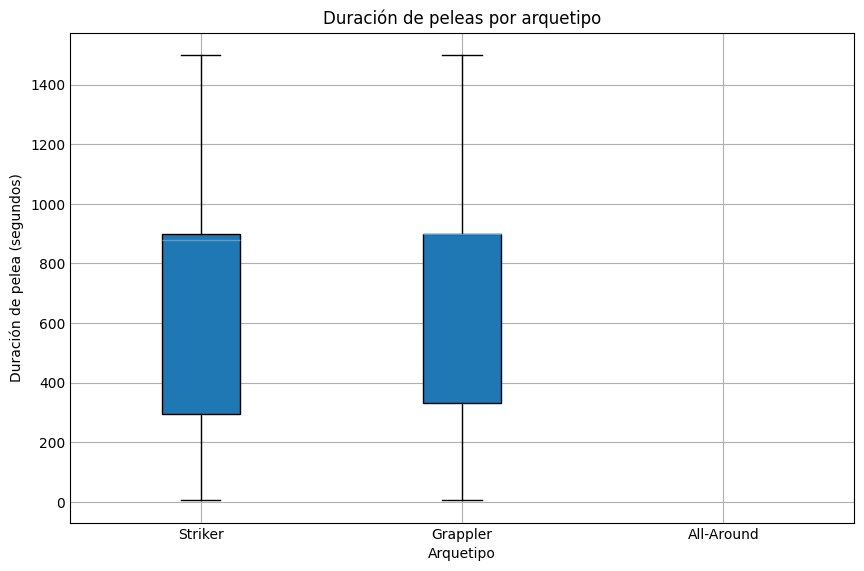

In [102]:
plt.style.use('_mpl-gallery')

arquetipos = ['Striker', 'Grappler', 'All-Around']
data = [
    df_arq_time[df_arq_time['arquetipo_winner'] == arq]['total_fight_time_secs'].dropna()
    for arq in arquetipos
]

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(data, labels=arquetipos, patch_artist=True)
ax.set_xlabel('Arquetipo')
ax.set_ylabel('Duración de pelea (segundos)')
ax.set_title('Duración de peleas por arquetipo')
plt.show()

/tmp/ipykernel_2729/1798596815.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=arquetipos, patch_artist=True)


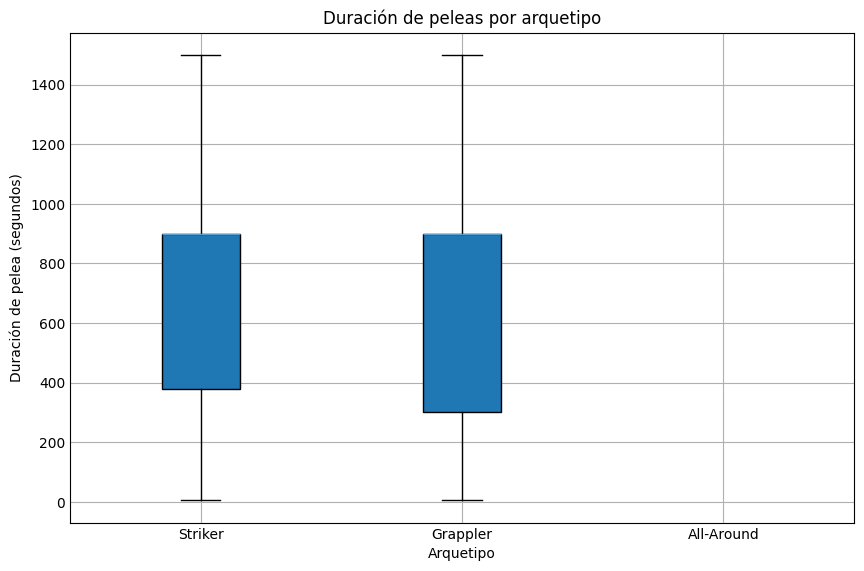

In [103]:
plt.style.use('_mpl-gallery')

arquetipos = ['Striker', 'Grappler', 'All-Around']
data = [
    df_arq_time[df_arq_time['arquetipo_losser'] == arq]['total_fight_time_secs'].dropna()
    for arq in arquetipos
]

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(data, labels=arquetipos, patch_artist=True)
ax.set_xlabel('Arquetipo')
ax.set_ylabel('Duración de pelea (segundos)')
ax.set_title('Duración de peleas por arquetipo')
plt.show()

/home/scoria/anaconda3/envs/j_notebook/lib/python3.10/site-packages/numpy/lib/_histograms_impl.py:901: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


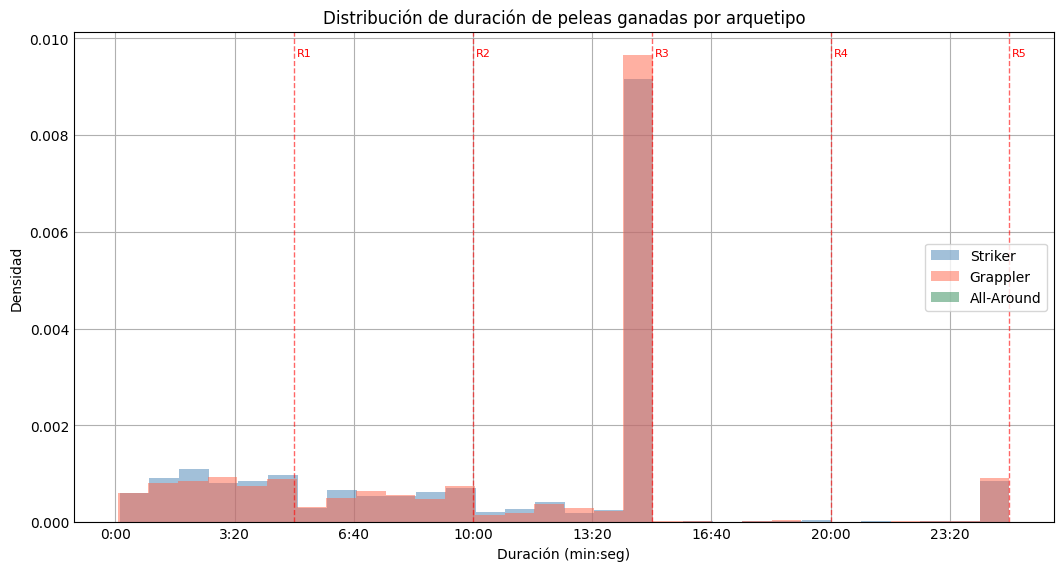

In [104]:
fig, ax = plt.subplots(figsize=(10, 5))

colores = {'Striker': 'steelblue', 'Grappler': 'tomato', 'All-Around': 'seagreen'}

for arq, color in colores.items():
    subset = df_arq_time[df_arq_time['arquetipo_winner'] == arq]['total_fight_time_secs'].dropna()
    ax.hist(subset, bins=30, alpha=0.5, label=arq, color=color, density=True)

# Líneas de round
for round_num in range(1, 6):
    ax.axvline(x=round_num * 300, color='red', linestyle='--', alpha=0.6, linewidth=1)
    ax.text(round_num * 300 + 5, ax.get_ylim()[1] * 0.95, f'R{round_num}', 
            color='red', fontsize=8)

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x//60)}:{int(x%60):02d}'))
ax.set_xlabel('Duración (min:seg)')
ax.set_ylabel('Densidad')
ax.set_title('Distribución de duración de peleas ganadas por arquetipo')
ax.legend()
plt.show()

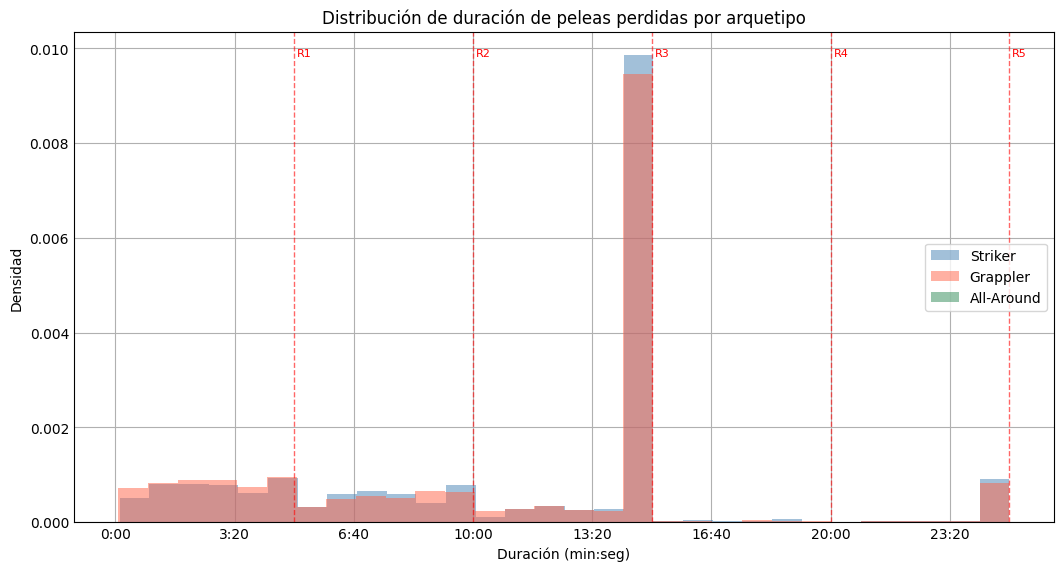

In [105]:
fig, ax = plt.subplots(figsize=(10, 5))

colores = {'Striker': 'steelblue', 'Grappler': 'tomato', 'All-Around': 'seagreen'}

for arq, color in colores.items():
    subset = df_arq_time[df_arq_time['arquetipo_losser'] == arq]['total_fight_time_secs'].dropna()
    ax.hist(subset, bins=30, alpha=0.5, label=arq, color=color, density=True)

# Líneas de round
for round_num in range(1, 6):
    ax.axvline(x=round_num * 300, color='red', linestyle='--', alpha=0.6, linewidth=1)
    ax.text(round_num * 300 + 5, ax.get_ylim()[1] * 0.95, f'R{round_num}', 
            color='red', fontsize=8)

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x//60)}:{int(x%60):02d}'))
ax.set_xlabel('Duración (min:seg)')
ax.set_ylabel('Densidad')
ax.set_title('Distribución de duración de peleas perdidas por arquetipo')
ax.legend()
plt.show()

In [106]:
df_record_arq = df_peleador_record.merge(
    df_peleador_acciones[['fighter', 'arquetipo_base']],
    on='fighter', how='left'
).dropna(subset=['arquetipo_base'])

# 2. Calcular win_rate por arquetipo
df_record_arq['win_rate'] = df_record_arq['wins'] / df_record_arq['total_fights']
df_record_arq['loss_rate'] = df_record_arq['losses'] / df_record_arq['total_fights']
df_record_arq['draw_rate'] = df_record_arq['draws'] / df_record_arq['total_fights']

# 3. Agrupar por arquetipo
df_arq_stats = df_record_arq.groupby('arquetipo_base').agg(
    win_rate=('win_rate', 'mean'),
    loss_rate=('loss_rate', 'mean'),
    draw_rate=('draw_rate', 'mean'),
    n_fighters=('fighter', 'count')
).reset_index()

print(df_arq_stats)  # Validar antes de graficar

  arquetipo_base  win_rate  loss_rate  draw_rate  n_fighters
0       Completo  0.324240   0.674979   0.000781         939
1       Grappler  0.471345   0.527852   0.000803         909
2        Striker  0.372998   0.626881   0.000121         393


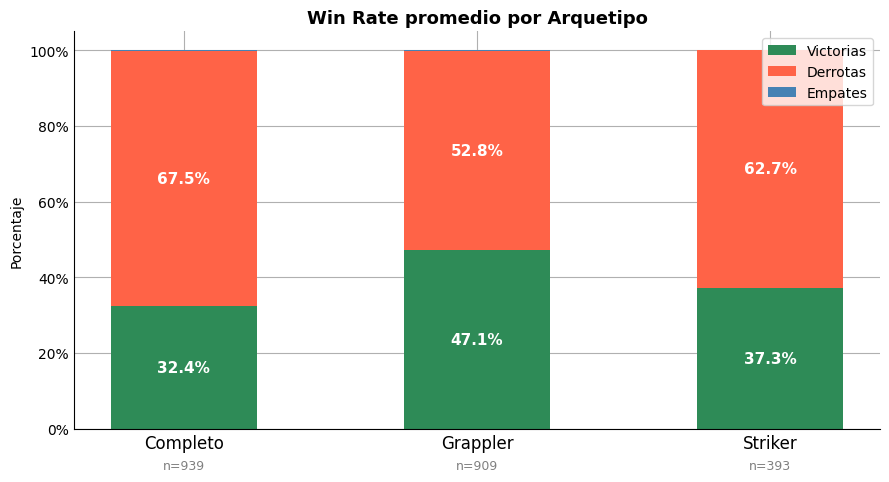

In [107]:
fig, ax = plt.subplots(figsize=(9, 5))

arquetipos = df_arq_stats['arquetipo_base']
x = np.arange(len(arquetipos))
width = 0.5

colores = {
    'win_rate':  'seagreen',
    'loss_rate': 'tomato',
    'draw_rate': 'steelblue'
}

bars_w = ax.bar(x, df_arq_stats['win_rate'],  width, label='Victorias', color=colores['win_rate'])
bars_l = ax.bar(x, df_arq_stats['loss_rate'], width, label='Derrotas',  color=colores['loss_rate'],
                bottom=df_arq_stats['win_rate'])
bars_d = ax.bar(x, df_arq_stats['draw_rate'], width, label='Empates',   color=colores['draw_rate'],
                bottom=df_arq_stats['win_rate'] + df_arq_stats['loss_rate'])

# Etiquetas de % dentro de cada barra
for i, row in df_arq_stats.iterrows():
    # Win
    ax.text(i, row['win_rate'] / 2,
            f"{row['win_rate']:.1%}", ha='center', va='center',
            fontsize=11, fontweight='bold', color='white')
    # Loss
    ax.text(i, row['win_rate'] + row['loss_rate'] / 2,
            f"{row['loss_rate']:.1%}", ha='center', va='center',
            fontsize=11, fontweight='bold', color='white')

# N de peleadores bajo cada barra
for i, row in df_arq_stats.iterrows():
    ax.text(i, -0.08, f"n={int(row['n_fighters'])}",
            ha='center', va='top', fontsize=9, color='gray')

ax.set_xticks(x)
ax.set_xticklabels(arquetipos, fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.set_ylim(0, 1.05)
ax.set_ylabel('Porcentaje')
ax.set_title('Win Rate promedio por Arquetipo', fontsize=13, fontweight='bold')
ax.legend(loc='upper right')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

In [108]:
def contar_finalizaciones(nombre, indices, df_ufc):
    if not indices:
        return pd.Series({'total_ko': 0, 'total_sub': 0, 'total_dec': 0})
    
    peleas = df_ufc.loc[indices, ['finish', 'Winner', 'R_fighter', 'B_fighter']]
    
    ko = sub = dec = 0
    
    for _, row in peleas.iterrows():
        gano = (row['Winner'] == 'Red'  and row['R_fighter'] == nombre) or \
               (row['Winner'] == 'Blue' and row['B_fighter'] == nombre)
        
        if not gano:
            continue

        f = str(row['finish']).strip()
        
        # Ajusta estos valores según el print de arriba
        if f in ['KO/TKO', 'TKO', 'TKO - Doctor\'s Stop']:
            ko  += 1
        elif f in ['SUB', 'Submission']:
            sub += 1
        elif f in ['DEC', 'S-DEC', 'M-DEC', 'U-DEC']:
            dec += 1
        #else:
            # Ver qué casos no estamos capturando
            #print(f"Sin clasificar → {nombre}: '{f}'")
    
    return pd.Series({'total_ko': ko, 'total_sub': sub, 'total_dec': dec})

In [109]:
df_fin = df_peleador_record.apply(
    lambda row: contar_finalizaciones(row['fighter'], row['indices_peleas'], df_ufc),
    axis=1
)

df_peleador_record = pd.concat([df_peleador_record, df_fin], axis=1)

In [110]:
test = ['Conor McGregor', 'Khabib Nurmagomedov', 'Jon Jones']
df_peleador_record[
    df_peleador_record['fighter'].isin(test)
][['fighter', 'wins', 'total_ko', 'total_sub', 'total_dec']]

,fighter,wins,total_ko,total_sub,total_dec
91,Jon Jones,19,6,4,8
413,Khabib Nurmagomedov,13,2,5,6
434,Conor McGregor,10,8,0,2


In [111]:
# ── DF BASE ────────────────────────────────────────────────────────
df_base = df_peleador_record.merge(
    df_peleador_acciones[['fighter', 'arquetipo_base']],
    on='fighter', how='left'
).dropna(subset=['arquetipo_base'])

df_base['ko_rate']  = df_base['total_ko']  / df_base['wins']
df_base['sub_rate'] = df_base['total_sub'] / df_base['wins']
df_base['dec_rate'] = df_base['total_dec'] / df_base['wins']

# Agrupar por arquetipo
finish_arq = df_base.groupby('arquetipo_base').agg(
    ko_rate  = ('ko_rate',  'mean'),
    sub_rate = ('sub_rate', 'mean'),
    dec_rate = ('dec_rate', 'mean'),
    n        = ('fighter',  'count')
).reset_index()

print(finish_arq)

  arquetipo_base   ko_rate  sub_rate  dec_rate    n
0       Completo  0.366609  0.112448  0.452676  939
1       Grappler  0.197184  0.252582  0.508846  909
2        Striker  0.369232  0.083917  0.474804  393


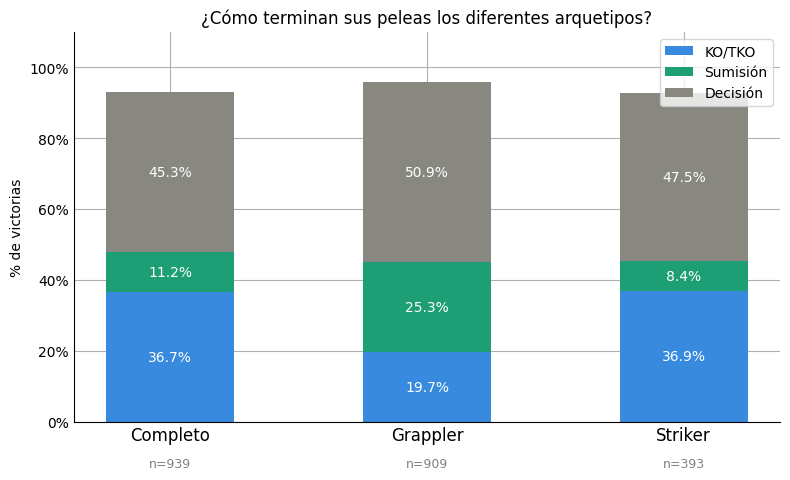

In [112]:
arquetipos = finish_arq['arquetipo_base'].tolist()
x = np.arange(len(arquetipos))
w = 0.5

fig, ax = plt.subplots(figsize=(8, 5))

b1 = ax.bar(x, finish_arq['ko_rate'],  w, label='KO/TKO',  color='#378ADD')
b2 = ax.bar(x, finish_arq['sub_rate'], w, label='Sumisión', color='#1D9E75',
            bottom=finish_arq['ko_rate'])
b3 = ax.bar(x, finish_arq['dec_rate'], w, label='Decisión', color='#888780',
            bottom=finish_arq['ko_rate'] + finish_arq['sub_rate'])

# Etiquetas dentro de cada segmento
for i, row in finish_arq.iterrows():
    # KO
    if row['ko_rate'] > 0.03:
        ax.text(i, row['ko_rate'] / 2,
                f"{row['ko_rate']:.1%}", ha='center', va='center',
                fontsize=10, color='white', fontweight='500')
    # SUB
    if row['sub_rate'] > 0.03:
        ax.text(i, row['ko_rate'] + row['sub_rate'] / 2,
                f"{row['sub_rate']:.1%}", ha='center', va='center',
                fontsize=10, color='white', fontweight='500')
    # DEC
    if row['dec_rate'] > 0.03:
        ax.text(i, row['ko_rate'] + row['sub_rate'] + row['dec_rate'] / 2,
                f"{row['dec_rate']:.1%}", ha='center', va='center',
                fontsize=10, color='white', fontweight='500')
    # N peleadores
    ax.text(i, -0.10, f"n={int(row['n'])}",
            ha='center', va='top', fontsize=9, color='gray')

ax.set_xticks(x)
ax.set_xticklabels(arquetipos, fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.set_ylim(0, 1.1)
ax.set_ylabel('% de victorias')
ax.set_title('¿Cómo terminan sus peleas los diferentes arquetipos?', fontweight='500')
ax.legend(loc='upper right')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

In [113]:
# Verificar nombre exacto de la columna
print(df_ufc['finish'].unique())
print(df_ufc['weight_class'].unique())

# ── DF DIVISIÓN ────────────────────────────────────────────────────
orden_divisiones = [
    "Women's Strawweight", "Women's Flyweight", "Women's Bantamweight",
    "Strawweight", "Flyweight", "Bantamweight", "Featherweight",
    "Lightweight", "Welterweight", "Middleweight",
    "Light Heavyweight", "Heavyweight"
]

# Filtrar solo divisiones presentes en el dataset
orden_divisiones = [d for d in orden_divisiones if d in df_ufc['weight_class'].unique()]

labels_cortos = {
    "Women's Strawweight": "W.Straw", "Women's Flyweight": "W.Fly",
    "Women's Bantamweight": "W.Bantam", "Strawweight": "Straw",
    "Flyweight": "Fly",               "Bantamweight": "Bantam",
    "Featherweight": "Feather",       "Lightweight": "Light",
    "Welterweight": "Welter",         "Middleweight": "Middle",
    "Light Heavyweight": "LHW",       "Heavyweight": "Heavy"
}

df_div = df_ufc[['weight_class', 'total_fight_time_secs', 'finish']].dropna()

div_stats = df_div.groupby('weight_class').agg(
    mediana_secs = ('total_fight_time_secs', 'median'),
    media_secs   = ('total_fight_time_secs', 'mean'),
    ko_pct       = ('finish', lambda x: (x.isin(['KO/TKO', 'TKO', "TKO - Doctor's Stop"])).mean()),
    sub_pct      = ('finish', lambda x: (x.isin(['SUB', 'Submission'])).mean()),
    dec_pct      = ('finish', lambda x: (x.isin(['DEC', 'S-DEC', 'M-DEC', 'U-DEC'])).mean()),
    n_peleas     = ('finish', 'count')
).reindex(orden_divisiones).dropna()

print(div_stats)

['U-DEC' 'KO/TKO' 'S-DEC' 'SUB' 'DQ' 'M-DEC' nan 'Overturned' 'CNC']
['Light Heavyweight' 'Heavyweight' 'Middleweight' 'Welterweight'
 'Lightweight' 'Featherweight' 'Bantamweight' 'Catch Weight' 'Flyweight'
 "Women's Bantamweight" "Women's Strawweight" "Women's Flyweight"
 "Women's Featherweight"]
                      mediana_secs  media_secs    ko_pct   sub_pct   dec_pct  \
weight_class                                                                   
Women's Strawweight          900.0  768.958333  0.134615  0.201923  0.660256   
Women's Flyweight            900.0  757.820513  0.158120  0.205128  0.636752   
Women's Bantamweight         900.0  729.454545  0.231818  0.177273  0.590909   
Flyweight                    900.0  706.201102  0.247934  0.203857  0.545455   
Bantamweight                 900.0  695.192253  0.248207  0.199426  0.550933   
Featherweight                900.0  672.606815  0.297510  0.171691  0.528178   
Lightweight                  891.0  642.979034  0.306290  0.2

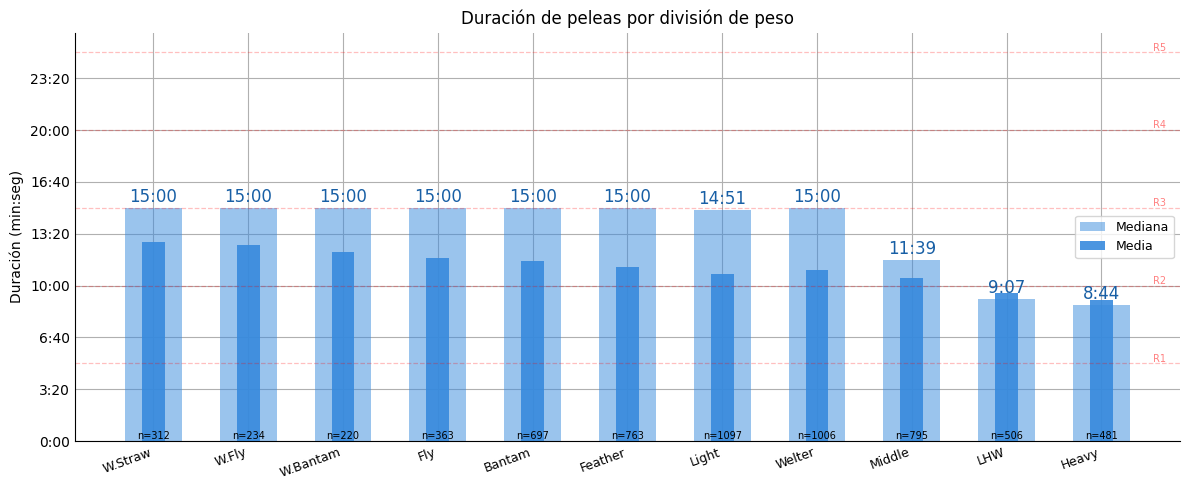

In [114]:
fig, ax1 = plt.subplots(figsize=(12, 5))
x = np.arange(len(div_stats))
xtick_labels = [labels_cortos.get(d, d) for d in div_stats.index]
w = 0.6

ax1.bar(x, div_stats['mediana_secs'], w, color='#378ADD', alpha=0.5, label='Mediana')
ax1.bar(x, div_stats['media_secs'],   w * 0.4, color='#378ADD', alpha=0.9, label='Media')

for i, (_, row) in enumerate(div_stats.iterrows()):
    mins = int(row['mediana_secs'] // 60)
    secs = int(row['mediana_secs'] % 60)
    ax1.text(i, row['mediana_secs'] + 8, f"{mins}:{secs:02d}",
             ha='center', va='bottom', fontsize=12, color='#185FA5')

for r in range(1, 6):
    ax1.axhline(r * 300, color='red', linestyle='--', alpha=0.25, linewidth=0.9)
    ax1.text(len(x) - 0.45, r * 300 + 6, f'R{r}',
             color='red', fontsize=7, alpha=0.5)

for i, (_, row) in enumerate(div_stats.iterrows()):
    ax1.text(i, 0, f"n={int(row['n_peleas'])}",
             ha='center', va='bottom', fontsize=7, color='black')

ax1.set_xticks(x)
ax1.set_xticklabels(xtick_labels, fontsize=9, rotation=20, ha='right')
ax1.set_ylabel('Duración (min:seg)')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(
    lambda y, _: f"{int(y//60)}:{int(y%60):02d}"))
ax1.set_title('Duración de peleas por división de peso', fontweight='500')
ax1.legend(fontsize=9)
ax1.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

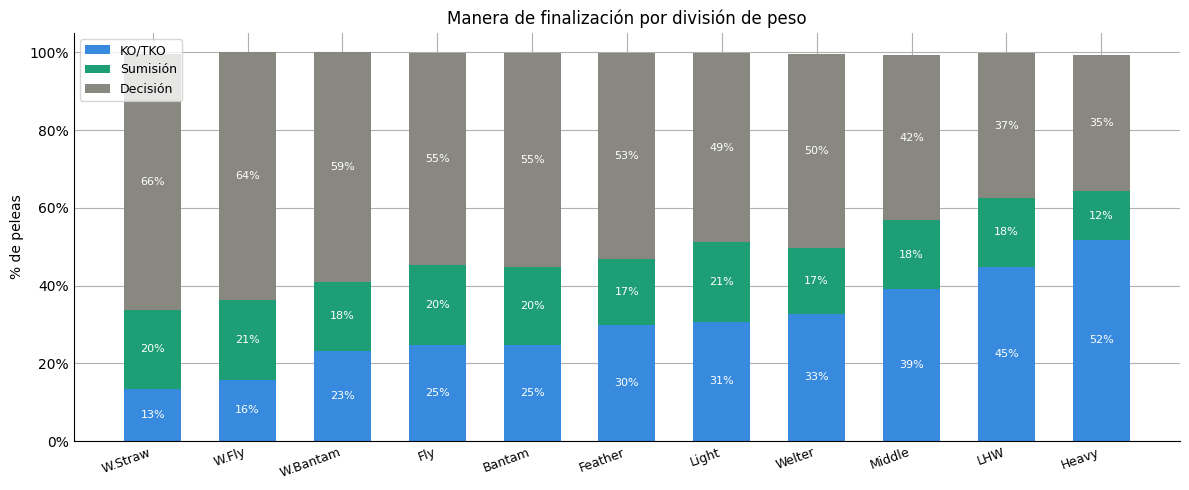

In [115]:
fig, ax2 = plt.subplots(figsize=(12, 5))

ax2.bar(x, div_stats['ko_pct'],  w, label='KO/TKO',  color='#378ADD')
ax2.bar(x, div_stats['sub_pct'], w, label='Sumisión', color='#1D9E75',
        bottom=div_stats['ko_pct'])
ax2.bar(x, div_stats['dec_pct'], w, label='Decisión', color='#888780',
        bottom=div_stats['ko_pct'] + div_stats['sub_pct'])

for i, (_, row) in enumerate(div_stats.iterrows()):
    if row['ko_pct'] > 0.05:
        ax2.text(i, row['ko_pct'] / 2,
                 f"{row['ko_pct']:.0%}", ha='center', va='center',
                 fontsize=8, color='white', fontweight='500')
    if row['sub_pct'] > 0.05:
        ax2.text(i, row['ko_pct'] + row['sub_pct'] / 2,
                 f"{row['sub_pct']:.0%}", ha='center', va='center',
                 fontsize=8, color='white', fontweight='500')
    if row['dec_pct'] > 0.05:
        ax2.text(i, row['ko_pct'] + row['sub_pct'] + row['dec_pct'] / 2,
                 f"{row['dec_pct']:.0%}", ha='center', va='center',
                 fontsize=8, color='white', fontweight='500')

ax2.set_xticks(x)
ax2.set_xticklabels(xtick_labels, fontsize=9, rotation=20, ha='right')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax2.set_ylabel('% de peleas')
ax2.set_title('Manera de finalización por división de peso', fontweight='500')
ax2.legend(loc='upper left', fontsize=9)
ax2.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

In [116]:
# 1. Merge record + arquetipos + acciones
df_analisis = df_peleador_record.merge(
    df_peleador_acciones[['fighter', 'arquetipo_base', 
                           'avg_SIG_STR_landed', 'avg_SIG_STR_pct',
                           'avg_SUB_ATT', 'avg_TD_landed', 'avg_TD_pct']],
    on='fighter', how='left'
).dropna(subset=['arquetipo_base'])

# 2. Promedio de acciones por arquetipo
df_acciones_arq = df_analisis.groupby('arquetipo_base').agg(
    sig_str  = ('avg_SIG_STR_landed', 'mean'),
    str_pct  = ('avg_SIG_STR_pct',    'mean'),
    sub_att  = ('avg_SUB_ATT',        'mean'),
    td_land  = ('avg_TD_landed',      'mean'),
    td_pct   = ('avg_TD_pct',         'mean'),
).reset_index()

print(df_acciones_arq)

  arquetipo_base    sig_str   str_pct   sub_att   td_land    td_pct
0       Completo  11.754470  0.429938  0.257540  0.548942  0.237356
1       Grappler  14.696537  0.467069  0.835164  2.445258  0.434782
2        Striker  33.213030  0.438124  0.166129  0.358157  0.177760


NameError: name 'mticker' is not defined

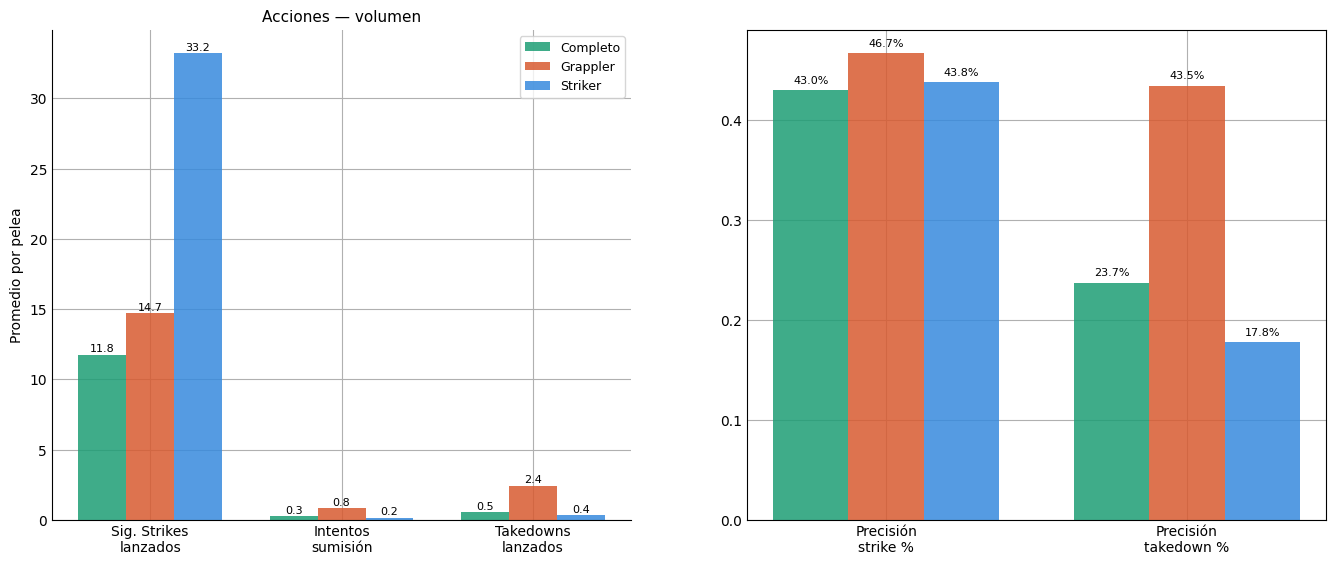

In [117]:

# 1. Agrupar métricas por arquetipo
df_acciones_arq = df_analisis.groupby('arquetipo_base').agg(
    sig_str = ('avg_SIG_STR_landed', 'mean'),
    str_pct = ('avg_SIG_STR_pct',    'mean'),
    sub_att = ('avg_SUB_ATT',        'mean'),
    td_land = ('avg_TD_landed',      'mean'),
    td_pct  = ('avg_TD_pct',         'mean'),
).reset_index()

# 2. Separar métricas por tipo (volumen vs precisión)
metricas_volumen   = ['sig_str', 'sub_att', 'td_land']
metricas_precision = ['str_pct', 'td_pct']

labels_volumen   = ['Sig. Strikes\nlanzados', 'Intentos\nsumisión', 'Takedowns\nlanzados']
labels_precision = ['Precisión\nstrike %', 'Precisión\ntakedown %']

arquetipos = df_acciones_arq['arquetipo_base'].tolist()
colores    = {'Striker': '#378ADD', 'Grappler': '#D85A30', 'Completo': '#1D9E75'}

x_vol = np.arange(len(metricas_volumen))
x_pre = np.arange(len(metricas_precision))
width = 0.25

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# --- Panel izquierdo: Volumen ---
for i, arq in enumerate(arquetipos):
    row = df_acciones_arq[df_acciones_arq['arquetipo_base'] == arq].iloc[0]
    vals = [row[m] for m in metricas_volumen]
    offset = (i - 1) * width
    bars = ax1.bar(x_vol + offset, vals, width, label=arq,
                   color=colores[arq], alpha=0.85)
    for bar, v in zip(bars, vals):
        ax1.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.05,
                 f'{v:.1f}', ha='center', va='bottom', fontsize=8)

ax1.set_xticks(x_vol)
ax1.set_xticklabels(labels_volumen, fontsize=10)
ax1.set_ylabel('Promedio por pelea')
ax1.set_title('Acciones — volumen', fontsize=11)
ax1.spines[['top', 'right']].set_visible(False)
ax1.legend(fontsize=9)

# --- Panel derecho: Precisión ---
for i, arq in enumerate(arquetipos):
    row = df_acciones_arq[df_acciones_arq['arquetipo_base'] == arq].iloc[0]
    vals = [row[m] for m in metricas_precision]
    offset = (i - 1) * width
    bars = ax2.bar(x_pre + offset, vals, width, label=arq,
                   color=colores[arq], alpha=0.85)
    for bar, v in zip(bars, vals):
        ax2.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.005,
                 f'{v:.1%}', ha='center', va='bottom', fontsize=8)

ax2.set_xticks(x_pre)
ax2.set_xticklabels(labels_precision, fontsize=10)
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax2.set_title('Acciones — precisión', fontsize=11)
ax2.spines[['top', 'right']].set_visible(False)
ax2.legend(fontsize=9)

fig.suptitle('¿Qué acciones ejecuta más cada arquetipo?',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [118]:
print(df_ufc['title_bout'].value_counts())

title_bout
False    6847
True      330
Name: count, dtype: int64


In [119]:
cols_perf = [
    'R_avg_SIG_STR_landed', 'R_avg_SIG_STR_pct',
    'R_avg_TD_landed',       'R_avg_TD_pct',
    'R_avg_SUB_ATT',
    'B_avg_SIG_STR_landed', 'B_avg_SIG_STR_pct',
    'B_avg_TD_landed',       'B_avg_TD_pct',
    'B_avg_SUB_ATT',
    'title_bout'
]

df_titulo = df_ufc[cols_perf].copy()

df_red_t = df_titulo[['R_avg_SIG_STR_landed', 'R_avg_SIG_STR_pct',
                       'R_avg_TD_landed', 'R_avg_TD_pct', 
                       'R_avg_SUB_ATT', 'title_bout']].rename(columns=lambda c: c.replace('R_', ''))

df_blue_t = df_titulo[['B_avg_SIG_STR_landed', 'B_avg_SIG_STR_pct',
                        'B_avg_TD_landed', 'B_avg_TD_pct',
                        'B_avg_SUB_ATT', 'title_bout']].rename(columns=lambda c: c.replace('B_', ''))

df_long_titulo = pd.concat([df_red_t, df_blue_t], ignore_index=True)
df_long_titulo['tipo'] = df_long_titulo['title_bout'].map({True: 'Título', False: 'Normal'})

df_comp = df_long_titulo.groupby('tipo').agg(
    sig_str = ('avg_SIG_STR_landed', 'mean'),
    str_pct = ('avg_SIG_STR_pct',    'mean'),
    td_land = ('avg_TD_landed',      'mean'),
    td_pct  = ('avg_TD_pct',         'mean'),
    sub_att = ('avg_SUB_ATT',        'mean'),
).reset_index()

print(df_comp)

     tipo    sig_str   str_pct   td_land    td_pct   sub_att
0  Normal  17.944638  0.454878  1.374367  0.333648  0.535988
1  Título  23.826969  0.480372  1.727274  0.394459  0.519306


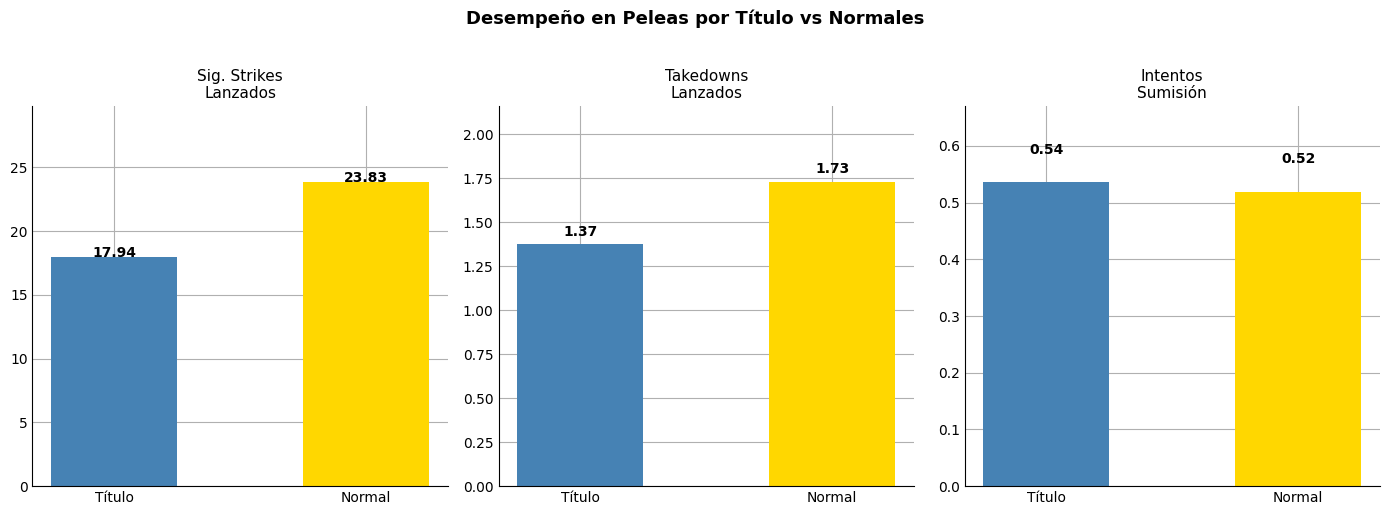

In [120]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

metricas = {
    'Sig. Strikes\nLanzados' : 'sig_str',
    'Takedowns\nLanzados'    : 'td_land',
    'Intentos\nSumisión'     : 'sub_att',
}
colores_tipo = {'Título': 'gold', 'Normal': 'steelblue'}

for ax, (label, col) in zip(axes, metricas.items()):
    for i, (_, row) in enumerate(df_comp.iterrows()):
        bar = ax.bar(i, row[col], color=colores_tipo[row['tipo']], 
                     width=0.5, label=row['tipo'])
        ax.text(i, row[col] + 0.05, f"{row[col]:.2f}", 
                ha='center', fontsize=10, fontweight='bold')
    
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Título', 'Normal'])
    ax.set_title(label, fontsize=11)
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_ylim(0, df_comp[col].max() * 1.25)

fig.suptitle('Desempeño en Peleas por Título vs Normales', 
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Analizando UFC 328

In [121]:
df_peleador_acciones.loc[df_peleador_acciones['fighter'] == 'Grant Dawson']

,fighter,avg_SIG_STR_landed,avg_SIG_STR_pct,avg_SUB_ATT,avg_TD_landed,avg_TD_pct,arquetipo_base
781,Grant Dawson,7.69,0.501667,1.416667,4.093333,0.405833,Grappler


In [122]:
df_peleador_record.loc[df_peleador_record['fighter'] == 'Grant Dawson']

,fighter,indices_peleas,total_fights,wins,losses,draws,current_win_streak,current_loss_streak,current_draw_streak,total_ko,total_sub,total_dec
1076,Grant Dawson,"[3647, 3759, 4137, 4291, 4627, 5180, 5454, 577...",13,11,2,0,0,1,0,2,4,5


In [123]:
df_peleador_acciones.loc[df_peleador_acciones['fighter'] == 'Mateusz Rebecki']

,fighter,avg_SIG_STR_landed,avg_SIG_STR_pct,avg_SUB_ATT,avg_TD_landed,avg_TD_pct,arquetipo_base
1443,Mateusz Rebecki,4.84,0.474286,0.828571,3.868571,0.684286,Grappler


In [124]:
df_peleador_record.loc[df_peleador_record['fighter'] == 'Mateusz Rebecki']

,fighter,indices_peleas,total_fights,wins,losses,draws,current_win_streak,current_loss_streak,current_draw_streak,total_ko,total_sub,total_dec
1473,Mateusz Rebecki,"[5531, 5771, 5975, 6216, 6459, 6844, 6976]",7,4,3,0,0,2,0,1,1,2


Considero ganará **Grant Dawson**

In [125]:
df_peleador_acciones.loc[df_peleador_acciones['fighter'] == 'Joel Alvarez']

,fighter,avg_SIG_STR_landed,avg_SIG_STR_pct,avg_SUB_ATT,avg_TD_landed,avg_TD_pct,arquetipo_base
1030,Joel Alvarez,7.812222,0.446,0.855556,0.021111,0.036667,Grappler


In [126]:
df_peleador_record.loc[df_peleador_record['fighter'] == 'Joel Alvarez']

,fighter,indices_peleas,total_fights,wins,losses,draws,current_win_streak,current_loss_streak,current_draw_streak,total_ko,total_sub,total_dec
1107,Joel Alvarez,"[3625, 3774, 4286, 4441, 4966, 5081, 5823, 634...",10,8,2,0,4,0,0,4,3,1


In [127]:
df_peleador_acciones.loc[df_peleador_acciones['fighter'] == 'Yaroslav Amosov']

,fighter,avg_SIG_STR_landed,avg_SIG_STR_pct,avg_SUB_ATT,avg_TD_landed,avg_TD_pct,arquetipo_base
2198,Yaroslav Amosov,2.78,0.47,4.6,4.64,0.5,Grappler


In [128]:
df_peleador_record.loc[df_peleador_record['fighter'] == 'Yaroslav Amosov']

,fighter,indices_peleas,total_fights,wins,losses,draws,current_win_streak,current_loss_streak,current_draw_streak,total_ko,total_sub,total_dec
2220,Yaroslav Amosov,[7054],1,1,0,0,1,0,0,0,1,0


Considero ganará **Joel Alvarez**

In [129]:
df_peleador_acciones.loc[df_peleador_acciones['fighter'] == 'Sean Brady']

,fighter,avg_SIG_STR_landed,avg_SIG_STR_pct,avg_SUB_ATT,avg_TD_landed,avg_TD_pct,arquetipo_base
1900,Sean Brady,4.943,0.546,0.8,3.011,0.571,Grappler


In [130]:
df_peleador_record.loc[df_peleador_record['fighter'] == 'Sean Brady']

,fighter,indices_peleas,total_fights,wins,losses,draws,current_win_streak,current_loss_streak,current_draw_streak,total_ko,total_sub,total_dec
1203,Sean Brady,"[3986, 4143, 4353, 4607, 4968, 5438, 5996, 638...",10,8,2,0,0,1,0,0,4,4


In [131]:
df_peleador_acciones.loc[df_peleador_acciones['fighter'] == 'Joaquin Buckley']

,fighter,avg_SIG_STR_landed,avg_SIG_STR_pct,avg_SUB_ATT,avg_TD_landed,avg_TD_pct,arquetipo_base
1012,Joaquin Buckley,3.924375,0.335,0.00625,1.3475,0.3425,Completo


In [132]:
df_peleador_record.loc[df_peleador_record['fighter'] == 'Joaquin Buckley']

,fighter,indices_peleas,total_fights,wins,losses,draws,current_win_streak,current_loss_streak,current_draw_streak,total_ko,total_sub,total_dec
1270,Joaquin Buckley,"[4323, 4416, 4484, 4527, 4864, 5066, 5251, 536...",16,11,5,0,0,1,0,8,0,3


Viendo las estadisticas creo que ganará **Sean Brady**

In [133]:
busq = df_peleador_acciones[df_peleador_acciones['fighter'].str.contains('Alek', na=False)]
print(busq)

                fighter  avg_SIG_STR_landed  avg_SIG_STR_pct  avg_SUB_ATT  \
49     Alekander Volkov                 NaN         0.600000      0.20000   
50         Aleksa Camur            5.156667         0.587500      0.00000   
51     Aleksandar Rakic           23.060367         0.494600      0.09000   
52   Aleksandre Topuria            2.930000         0.550000      0.00000   
53    Aleksei Kunchenko           17.080000         0.373333      0.00000   
54      Aleksei Oleinik            9.358820         0.485563      1.64375   
852     Irina Alekseeva            3.630000         0.405000      0.65000   

     avg_TD_landed  avg_TD_pct arquetipo_base  
49        0.750000    0.750000       Completo  
50        0.442500    0.242500       Completo  
51        0.856000    0.269500        Striker  
52        1.500000    0.330000       Completo  
53        0.553333    0.386667        Striker  
54        1.807369    0.342750       Grappler  
852       0.625000    0.200000       Completo  

In [134]:
df_peleador_acciones.loc[df_peleador_acciones['fighter'] == 'Alekander Volkov']

,fighter,avg_SIG_STR_landed,avg_SIG_STR_pct,avg_SUB_ATT,avg_TD_landed,avg_TD_pct,arquetipo_base
49,Alekander Volkov,NaN,0.6,0.2,0.75,0.75,Completo


In [135]:
df_peleador_record.loc[df_peleador_record['fighter'] == 'Alekander Volkov']

,fighter,indices_peleas,total_fights,wins,losses,draws,current_win_streak,current_loss_streak,current_draw_streak,total_ko,total_sub,total_dec
1167,Alekander Volkov,[4015],1,1,0,0,1,0,0,0,0,0


In [136]:
df_peleador_acciones.loc[df_peleador_acciones['fighter'] == 'Waldo Cortes-Acosta']

,fighter,avg_SIG_STR_landed,avg_SIG_STR_pct,avg_SUB_ATT,avg_TD_landed,avg_TD_pct,arquetipo_base
2162,Waldo Cortes-Acosta,5.64,0.48,0.2,0.55,0.6,Completo


In [137]:
df_peleador_record.loc[df_peleador_record['fighter'] == 'Waldo Cortes-Acosta']

,fighter,indices_peleas,total_fights,wins,losses,draws,current_win_streak,current_loss_streak,current_draw_streak,total_ko,total_sub,total_dec
1459,Waldo Cortes-Acosta,"[5439, 5477, 5684, 5878, 6031, 6218]",6,5,1,0,3,0,0,1,0,4


No conocemos lo suficiente de **Alekander Volkov** como para hacer un analisis.

In [138]:
df_peleador_caracteristicas.loc[df_peleador_caracteristicas['fighter'] == 'Joshua Van']

,fighter,Height_cms,Reach_cms,Weight_lbs,age,Stance
1125,Joshua Van,165.1,165.1,125,24,Orthodox


In [139]:
df_peleador_acciones.loc[df_peleador_acciones['fighter'] == 'Joshua Van']

,fighter,avg_SIG_STR_landed,avg_SIG_STR_pct,avg_SUB_ATT,avg_TD_landed,avg_TD_pct,arquetipo_base
1125,Joshua Van,8.618,0.539,0.0,1.182,0.591,Completo


In [140]:
df_peleador_record.loc[df_peleador_record['fighter'] == 'Joshua Van']

,fighter,indices_peleas,total_fights,wins,losses,draws,current_win_streak,current_loss_streak,current_draw_streak,total_ko,total_sub,total_dec
1566,Joshua Van,"[5767, 5978, 6037, 6304, 6400, 6523, 6634, 676...",10,9,1,0,6,0,0,3,0,6


In [141]:
nombre = 'Joshua Van'
indices = df_peleador_record.loc[
    df_peleador_record['fighter'] == nombre, 'indices_peleas'
].values[0]

df_ufc.loc[indices, cols_finish]

,R_fighter,B_fighter,Winner,finish,finish_details,finish_round,finish_round_time
5767,Zhalgas Zhumagulov,Joshua Van,Blue,S-DEC,NaN,3.0,5:00
5978,Joshua Van,Kevin Borjas,Red,U-DEC,NaN,3.0,5:00
6037,Joshua Van,Felipe Bunes,Red,KO/TKO,Punches,2.0,4:31
6304,Joshua Van,Charles Johnson,Blue,KO/TKO,Punch,3.0,0:20
6400,Edgar Chairez,Joshua Van,Blue,U-DEC,NaN,3.0,5:00
6523,Cody Durden,Joshua Van,Blue,U-DEC,NaN,3.0,5:00
6634,Joshua Van,Rei Tsuruya,Red,U-DEC,NaN,3.0,5:00
6761,Bruno Silva,Joshua Van,Blue,KO/TKO,Punches,3.0,4:01
6796,Brandon Royval,Joshua Van,Blue,U-DEC,NaN,3.0,5:00
7036,Alexandre Pantoja,Joshua Van,Blue,KO/TKO,NaN,1.0,0:26


In [142]:
df_peleador_caracteristicas.loc[df_peleador_caracteristicas['fighter'] == 'Tatsuro Taira']

,fighter,Height_cms,Reach_cms,Weight_lbs,age,Stance
2026,Tatsuro Taira,170.18,177.8,125,25,Orthodox


In [143]:
df_peleador_acciones.loc[df_peleador_acciones['fighter'] == 'Tatsuro Taira']

,fighter,avg_SIG_STR_landed,avg_SIG_STR_pct,avg_SUB_ATT,avg_TD_landed,avg_TD_pct,arquetipo_base
2026,Tatsuro Taira,3.295556,0.627778,1.877778,2.605556,0.461111,Grappler


In [144]:
df_peleador_record.loc[df_peleador_record['fighter'] == 'Tatsuro Taira']

,fighter,indices_peleas,total_fights,wins,losses,draws,current_win_streak,current_loss_streak,current_draw_streak,total_ko,total_sub,total_dec
1417,Tatsuro Taira,"[5210, 5425, 5558, 5796, 6013, 6264, 6429, 684...",9,8,1,0,2,0,0,3,3,2


In [145]:
nombre = 'Tatsuro Taira'
indices = df_peleador_record.loc[
    df_peleador_record['fighter'] == nombre, 'indices_peleas'
].values[0]

df_ufc.loc[indices, cols_finish]

,R_fighter,B_fighter,Winner,finish,finish_details,finish_round,finish_round_time
5210,Tatsuro Taira,Carlos Candelario,Red,U-DEC,NaN,3.0,5:00
5425,Tatsuro Taira,CJ Vergara,Red,SUB,Armbar,2.0,4:19
5558,Tatsuro Taira,Jesus Aguilar,Red,SUB,Triangle Armbar,1.0,4:20
5796,Tatsuro Taira,Edgar Chairez,Red,U-DEC,NaN,3.0,5:00
6013,Tatsuro Taira,Carlos Hernandez,Red,KO/TKO,Punches,2.0,0:55
6264,Alex Perez,Tatsuro Taira,Blue,KO/TKO,NaN,2.0,2:59
6429,Brandon Royval,Tatsuro Taira,Red,S-DEC,NaN,5.0,5:00
6843,Tatsuro Taira,HyunSung Park,Red,SUB,Neck Crank,2.0,1:06
7037,Brandon Moreno,Tatsuro Taira,Blue,KO/TKO,Punches,2.0,2:24


Viendo las estadisticas creo que ganará **Tatsuro Taira**

In [146]:
df_peleador_caracteristicas.loc[df_peleador_caracteristicas['fighter'] == 'Khamzat Chimaev']

,fighter,Height_cms,Reach_cms,Weight_lbs,age,Stance
1232,Khamzat Chimaev,187.96,190.5,185,31,Orthodox


In [147]:
df_peleador_acciones.loc[df_peleador_acciones['fighter'] == 'Khamzat Chimaev']

,fighter,avg_SIG_STR_landed,avg_SIG_STR_pct,avg_SUB_ATT,avg_TD_landed,avg_TD_pct,arquetipo_base
1232,Khamzat Chimaev,5.344444,0.56,2.333333,3.912222,0.511111,Grappler


In [148]:
df_peleador_record.loc[df_peleador_record['fighter'] == 'Khamzat Chimaev']

,fighter,indices_peleas,total_fights,wins,losses,draws,current_win_streak,current_loss_streak,current_draw_streak,total_ko,total_sub,total_dec
1231,Khamzat Chimaev,"[4274, 4297, 4378, 4932, 5142, 5380, 5948, 645...",9,9,0,0,9,0,0,2,4,3


In [149]:
nombre = 'Khamzat Chimaev'
indices = df_peleador_record.loc[
    df_peleador_record['fighter'] == nombre, 'indices_peleas'
].values[0]

df_ufc.loc[indices, cols_finish]

,R_fighter,B_fighter,Winner,finish,finish_details,finish_round,finish_round_time
4274,John Phillips,Khamzat Chimaev,Blue,SUB,D'Arce Choke,2.0,1:12
4297,Khamzat Chimaev,Rhys McKee,Red,KO/TKO,Punches,1.0,3:09
4378,Khamzat Chimaev,Gerald Meerschaert,Red,KO/TKO,NaN,NaN,NaN
4932,Li Jingliang,Khamzat Chimaev,Blue,SUB,Rear Naked Choke,1.0,3:16
5142,Gilbert Burns,Khamzat Chimaev,Blue,U-DEC,NaN,3.0,5:00
5380,Khamzat Chimaev,Kevin Holland,Red,SUB,D'Arce Choke,1.0,2:13
5948,Kamaru Usman,Khamzat Chimaev,Blue,M-DEC,NaN,3.0,5:00
6454,Robert Whittaker,Khamzat Chimaev,Blue,SUB,Rear Naked Choke,1.0,3:34
6868,Dricus Du Plessis,Khamzat Chimaev,Blue,U-DEC,NaN,5.0,5:00


In [150]:
df_peleador_caracteristicas.loc[df_peleador_caracteristicas['fighter'] == 'Sean Strickland']

,fighter,Height_cms,Reach_cms,Weight_lbs,age,Stance
1909,Sean Strickland,185.42,193.04,185,34,Orthodox


In [151]:
df_peleador_acciones.loc[df_peleador_acciones['fighter'] == 'Sean Strickland']

,fighter,avg_SIG_STR_landed,avg_SIG_STR_pct,avg_SUB_ATT,avg_TD_landed,avg_TD_pct,arquetipo_base
1909,Sean Strickland,21.127548,0.407261,0.376361,1.06377,0.56687,Completo


In [152]:
df_peleador_record.loc[df_peleador_record['fighter'] == 'Sean Strickland']

,fighter,indices_peleas,total_fights,wins,losses,draws,current_win_streak,current_loss_streak,current_draw_streak,total_ko,total_sub,total_dec
790,Sean Strickland,"[1307, 1402, 1772, 1970, 2233, 2351, 2754, 301...",24,17,7,0,1,0,0,5,0,11


In [153]:
nombre = 'Sean Strickland'
indices = df_peleador_record.loc[
    df_peleador_record['fighter'] == nombre, 'indices_peleas'
].values[0]

df_ufc.loc[indices, cols_finish]

,R_fighter,B_fighter,Winner,finish,finish_details,finish_round,finish_round_time
1307,Bubba McDaniel,Sean Strickland,Blue,NaN,NaN,NaN,NaN
1402,Luke Barnatt,Sean Strickland,Blue,S-DEC,NaN,3.0,5:00
1772,Santiago Ponzinibbio,Sean Strickland,Red,U-DEC,NaN,3.0,5:00
1970,Igor Araujo,Sean Strickland,Blue,U-DEC,NaN,3.0,5:00
2233,Alex Garcia,Sean Strickland,Blue,KO/TKO,Punches,3.0,4:25
2351,Sean Strickland,Tom Breese,Red,S-DEC,NaN,3.0,5:00
2754,Kamaru Usman,Sean Strickland,Red,U-DEC,NaN,3.0,5:00
3013,Court McGee,Sean Strickland,Blue,U-DEC,NaN,3.0,5:00
3239,Elizeu Zaleski dos Santos,Sean Strickland,Red,KO/TKO,Kick,1.0,3:40
3456,Nordine Taleb,Sean Strickland,Blue,KO/TKO,Punch,2.0,3:10


Viendo las estadisticas creo que ganará **Khamzat Chimaev** por sumisión en el tercer round.

| Mi favorito a ganar | Resultado | Información |
| :--- | :--- | :--- |
| Grant Dawson | Gana por sumisión - R3 04:42 | |
| Joel Alvarez | Pierde por sumisión - R2 01:13 | No teniamos suficiente información del rival para un analisis preciso |
| Sean Brady | Gana por decisión - R3 05:00 | Dominó al rival toda la pelea con su estilo de Grappler |
| Tatsuro Taira | Pierde por nocaut - R5 01:32 | Estuvo cerca de someter pero tuvo muchos problemas con los golpes del rival |
| Khamzat Chimaev | Pierde por decisión - R5 5:00 | No llevó la pelea como se esperaba, su rival aguantó sus intentos de derribo y al pelear de pie ambos Khamzat perdió por decisión |


In [154]:
busq = df_peleador_acciones[df_peleador_acciones['fighter'].str.contains('Charles', na=False)]
print(busq)

              fighter  avg_SIG_STR_landed  avg_SIG_STR_pct  avg_SUB_ATT  \
361      Charles Byrd           13.120000         0.680000     1.133333   
362   Charles Johnson            4.800000         0.502143     0.421429   
363  Charles Jourdain            5.343077         0.463800     0.471429   
364  Charles Oliveira           14.039415         0.523114     1.807240   
365    Charles Radtke            3.106667         0.528333     0.233333   
366      Charles Rosa           13.159725         0.347750     1.234725   

     avg_TD_landed  avg_TD_pct arquetipo_base  
361       1.340000    0.666667       Grappler  
362       0.455714    0.195000       Completo  
363       0.247857    0.161429       Completo  
364       1.448537    0.353886       Grappler  
365       0.843333    0.180000       Completo  
366       2.439167    0.388167       Grappler  


In [155]:
df_peleador_acciones.loc[df_peleador_acciones['fighter'] == 'Charles Oliveira']

,fighter,avg_SIG_STR_landed,avg_SIG_STR_pct,avg_SUB_ATT,avg_TD_landed,avg_TD_pct,arquetipo_base
364,Charles Oliveira,14.039415,0.523114,1.80724,1.448537,0.353886,Grappler


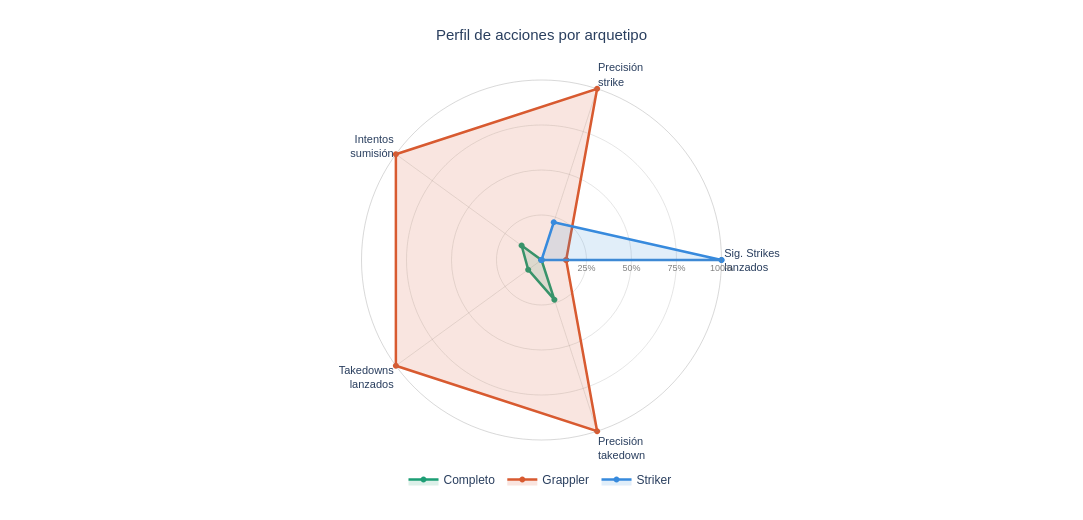

In [156]:
import plotly.graph_objects as go
import pandas as pd

# 1. Preparar datos por arquetipo
df_acciones_arq = df_analisis.groupby('arquetipo_base').agg(
    sig_str = ('avg_SIG_STR_landed', 'mean'),
    str_pct = ('avg_SIG_STR_pct',    'mean'),
    sub_att = ('avg_SUB_ATT',        'mean'),
    td_land = ('avg_TD_landed',      'mean'),
    td_pct  = ('avg_TD_pct',         'mean'),
).reset_index()

# 2. Normalizar 0-1 para que las métricas sean comparables
cols_norm = ['sig_str', 'str_pct', 'sub_att', 'td_land', 'td_pct']
df_norm = df_acciones_arq.copy()
for col in cols_norm:
    min_v = df_norm[col].min()
    max_v = df_norm[col].max()
    df_norm[col] = (df_norm[col] - min_v) / (max_v - min_v)

# 3. Config
categorias = [
    'Sig. Strikes<br>lanzados',
    'Precisión<br>strike',
    'Intentos<br>sumisión',
    'Takedowns<br>lanzados',
    'Precisión<br>takedown'
]

colores = {
    'Striker'  : ('#378ADD', 'rgba(55,138,221,0.15)'),
    'Grappler' : ('#D85A30', 'rgba(216,90,48,0.15)'),
    'Completo' : ('#1D9E75', 'rgba(29,158,117,0.15)'),
}

# 4. Construir figura
fig = go.Figure()

for _, row in df_norm.iterrows():
    arq = row['arquetipo_base']
    vals_norm = [row[c] for c in cols_norm]
    
    # Valores reales para el tooltip
    vals_real = df_acciones_arq[
        df_acciones_arq['arquetipo_base'] == arq
    ][cols_norm].values[0]
    
    labels_tooltip = [
        f'{cat.replace("<br>", " ")}: {real:.2f}'
        for cat, real in zip(categorias, vals_real)
    ]
    
    color_line, color_fill = colores[arq]
    
    fig.add_trace(go.Scatterpolar(
        r    = vals_norm + [vals_norm[0]],   # cerrar polígono
        theta= categorias + [categorias[0]],
        name = arq,
        text = labels_tooltip + [labels_tooltip[0]],
        hovertemplate = '%{text}<extra></extra>',
        line = dict(color=color_line, width=2.5),
        fill = 'toself',
        fillcolor = color_fill,
        marker = dict(size=6, color=color_line),
    ))

# 5. Layout
fig.update_layout(
    polar=dict(
        bgcolor='rgba(0,0,0,0)',
        radialaxis=dict(
            visible=True,
            range=[0, 1],
            tickvals=[0.25, 0.5, 0.75, 1.0],
            ticktext=['25%', '50%', '75%', '100%'],
            tickfont=dict(size=9, color='gray'),
            gridcolor='rgba(128,128,128,0.2)',
            linecolor='rgba(128,128,128,0.2)',
        ),
        angularaxis=dict(
            tickfont=dict(size=11),
            gridcolor='rgba(128,128,128,0.2)',
            linecolor='rgba(128,128,128,0.3)',
        ),
    ),
    legend=dict(
        orientation='h',
        yanchor='bottom',
        y=-0.15,
        xanchor='center',
        x=0.5,
        font=dict(size=12),
    ),
    title=dict(
        text='Perfil de acciones por arquetipo',
        x=0.5,
        font=dict(size=15),
    ),
    paper_bgcolor='rgba(0,0,0,0)',
    plot_bgcolor='rgba(0,0,0,0)',
    height=520,
    margin=dict(t=80, b=80, l=80, r=80),
)

fig.show()

In [157]:
# En Streamlit
peleadores = st.multiselect(
    'Selecciona peleadores',
    options=df_peleador_acciones['fighter'].tolist(),
    default=['Khabib Nurmagomedov', 'Conor McGregor']
)

NameError: name 'st' is not defined

In [158]:
# Normalización global — cada métrica se normaliza contra el máximo del dataset completo
# Calcular una sola vez fuera del gráfico
maximos_globales = {col: df_peleador_acciones[col].max() for col in cols_norm}

df_norm = df_sel.copy()
for col in cols_norm:
    max_global = maximos_globales[col]
    df_norm[col] = df_norm[col] / max_global if max_global > 0 else 0

KeyError: 'sig_str'

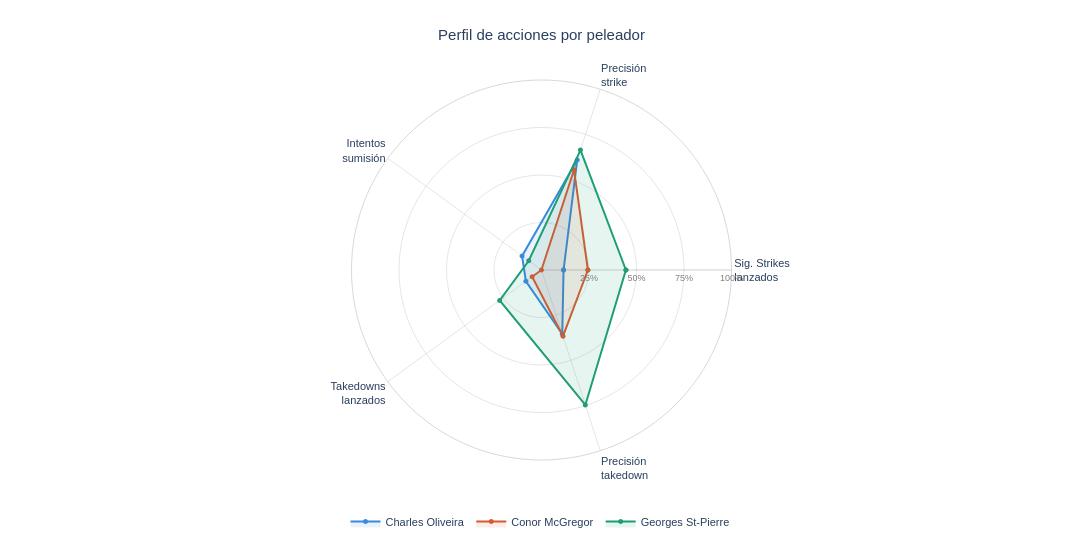

In [172]:
import plotly.graph_objects as go

peleadores = ['Charles Oliveira'
              , 'Georges St-Pierre', 'Conor McGregor'
             ]

df_sel = df_peleador_acciones[
    df_peleador_acciones['fighter'].isin(peleadores)
].copy()

cols_norm = ['avg_SIG_STR_landed', 'avg_SIG_STR_pct', 
             'avg_SUB_ATT', 'avg_TD_landed', 'avg_TD_pct']

categorias = [
    'Sig. Strikes<br>lanzados',
    'Precisión<br>strike',
    'Intentos<br>sumisión',
    'Takedowns<br>lanzados',
    'Precisión<br>takedown'
]

# ✅ Calcular máximos globales UNA SOLA VEZ, fuera del loop
maximos_globales = {col: df_peleador_acciones[col].max() for col in cols_norm}

df_norm = df_sel.copy()
for col in cols_norm:
    max_global = maximos_globales[col]
    # ✅ Siempre normalizar contra el máximo global — sin importar cuántos peleadores
    df_norm[col] = df_norm[col] / max_global if max_global > 0 else 0

colores = [
    ('#378ADD', 'rgba(55,138,221,0.10)'),
    ('#D85A30', 'rgba(216,90,48,0.10)'),
    ('#1D9E75', 'rgba(29,158,117,0.10)'),
    ('#9B59B6', 'rgba(155,89,182,0.10)'),
    ('#F39C12', 'rgba(243,156,18,0.10)'),
]

fig = go.Figure()

for i, (_, row_norm) in enumerate(df_norm.iterrows()):
    nombre   = row_norm['fighter']
    row_real = df_sel[df_sel['fighter'] == nombre].iloc[0]
    
    vals_norm = [row_norm[c] for c in cols_norm]
    tooltip   = [
        f'{cat.replace("<br>", " ")}: {row_real[col]:.2f}'
        for cat, col in zip(categorias, cols_norm)
    ]
    
    color_line, color_fill = colores[i % len(colores)]
    
    fig.add_trace(go.Scatterpolar(
        r             = vals_norm + [vals_norm[0]],
        theta         = categorias + [categorias[0]],
        name          = nombre,
        text          = tooltip + [tooltip[0]],
        hovertemplate = '%{text}<extra></extra>',
        line          = dict(color=color_line, width=2),
        fill          = 'toself',
        fillcolor     = color_fill,
        marker        = dict(size=5, color=color_line),
    ))

fig.update_layout(
    polar=dict(
        bgcolor='rgba(0,0,0,0)',
        radialaxis=dict(
            visible  = True,
            range    = [0, 1],
            tickvals = [0.25, 0.5, 0.75, 1.0],
            ticktext = ['25%', '50%', '75%', '100%'],
            tickfont = dict(size=9, color='gray'),
            gridcolor= 'rgba(128,128,128,0.2)',
            linecolor= 'rgba(128,128,128,0.2)',
        ),
        angularaxis=dict(
            tickfont = dict(size=11),
            gridcolor= 'rgba(128,128,128,0.2)',
            linecolor= 'rgba(128,128,128,0.3)',
        ),
    ),
    legend=dict(
        orientation='h',
        yanchor='bottom',
        y=-0.20,
        xanchor='center',
        x=0.5,
        font=dict(size=11),
    ),
    title=dict(
        text='Perfil de acciones por peleador',
        x=0.5,
        font=dict(size=15),
    ),
    paper_bgcolor='rgba(0,0,0,0)',
    plot_bgcolor ='rgba(0,0,0,0)',
    height=560,
    margin=dict(t=80, b=100, l=80, r=80),
)

fig.show()

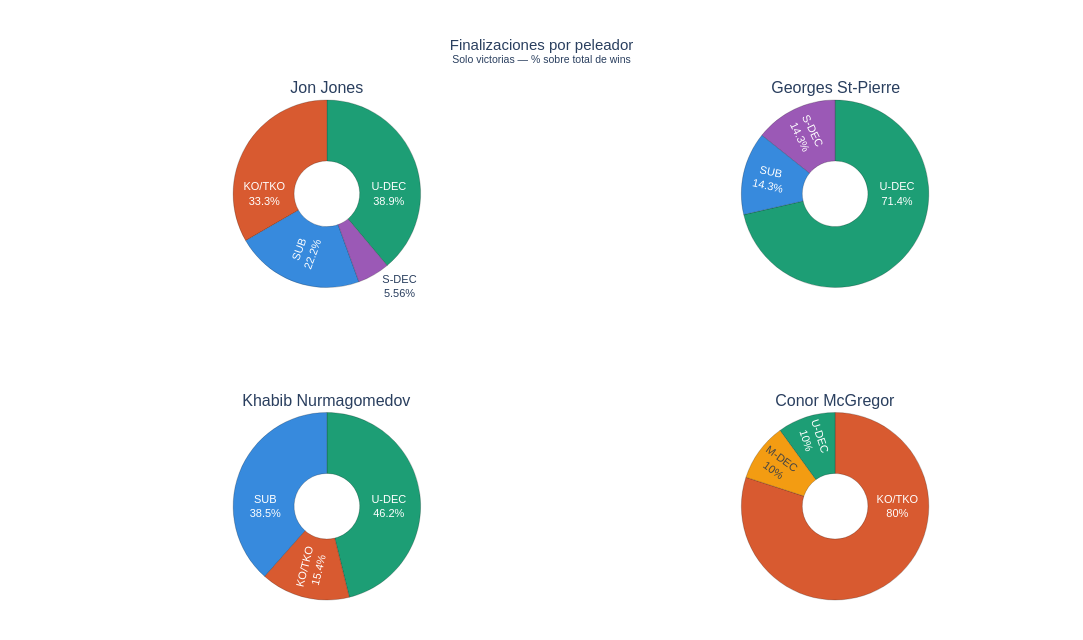

In [160]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 1. Seleccionar peleadores
peleadores = ['Jon Jones', 'Georges St-Pierre', 'Khabib Nurmagomedov', 'Conor McGregor']

# 2. Extraer finalizaciones por peleador desde df_ufc
def get_finalizaciones(nombre, df_ufc):
    mask = (df_ufc['R_fighter'] == nombre) | (df_ufc['B_fighter'] == nombre)
    peleas = df_ufc[mask][['finish', 'Winner', 'R_fighter', 'B_fighter']].copy()
    
    # Solo peleas donde ganó
    peleas_ganadas = peleas[
        ((peleas['Winner'] == 'Red')  & (peleas['R_fighter'] == nombre)) |
        ((peleas['Winner'] == 'Blue') & (peleas['B_fighter'] == nombre))
    ]
    
    return peleas_ganadas['finish'].value_counts()

# 3. Colores por tipo de finalización
color_map = {
    'KO/TKO' : '#D85A30',
    'SUB'     : '#378ADD',
    'DEC'     : '#1D9E75',
    'S-DEC'   : '#9B59B6',
    'M-DEC'   : '#F39C12',
    'U-DEC'   : '#1D9E75',
    'CNC'     : '#888780',
    'DQ'      : '#888780',
}

# 4. Subplots — una torta por peleador
n     = len(peleadores)
cols  = 2
rows  = (n + 1) // cols

specs = [[{'type': 'pie'} for _ in range(cols)] for _ in range(rows)]

fig = make_subplots(
    rows=rows, cols=cols,
    specs=specs,
    subplot_titles=peleadores,
)

for i, nombre in enumerate(peleadores):
    row = i // cols + 1
    col = i %  cols + 1
    
    finalizaciones = get_finalizaciones(nombre, df_ufc)
    
    if finalizaciones.empty:
        continue
    
    labels = finalizaciones.index.tolist()
    values = finalizaciones.values.tolist()
    colors = [color_map.get(l, '#888780') for l in labels]
    
    fig.add_trace(
        go.Pie(
            labels           = labels,
            values           = values,
            name             = nombre,
            marker           = dict(colors=colors, line=dict(color='rgba(0,0,0,0.2)', width=1)),
            textinfo         = 'label+percent',
            hovertemplate    = '<b>%{label}</b><br>Victorias: %{value}<br>%{percent}<extra>' + nombre + '</extra>',
            hole             = 0.35,       # donut — más legible
            textfont         = dict(size=11),
            insidetextorientation='radial',
        ),
        row=row, col=col
    )

# 5. Layout
fig.update_layout(
    title=dict(
        text='Finalizaciones por peleador<br><sup>Solo victorias — % sobre total de wins</sup>',
        x=0.5,
        font=dict(size=15),
    ),
    showlegend   = False,
    paper_bgcolor= 'rgba(0,0,0,0)',
    plot_bgcolor = 'rgba(0,0,0,0)',
    height       = rows * 320,
    margin       = dict(t=100, b=40, l=40, r=40),
)

fig.show()

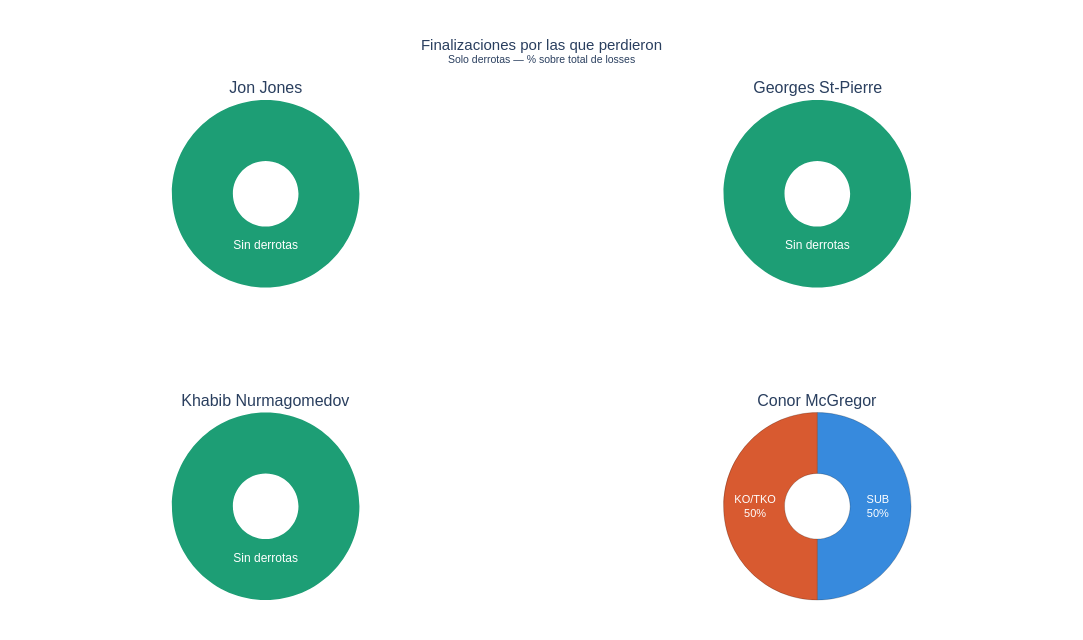

In [161]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 1. Seleccionar peleadores
peleadores = ['Jon Jones', 'Georges St-Pierre', 'Khabib Nurmagomedov', 'Conor McGregor']

# 2. Finalizaciones por las que PERDIÓ
def get_derrotas(nombre, df_ufc):
    mask = (df_ufc['R_fighter'] == nombre) | (df_ufc['B_fighter'] == nombre)
    peleas = df_ufc[mask][['finish', 'Winner', 'R_fighter', 'B_fighter']].copy()
    
    # ✅ Solo peleas donde perdió (invertido respecto al gráfico anterior)
    peleas_perdidas = peleas[
        ((peleas['Winner'] == 'Blue') & (peleas['R_fighter'] == nombre)) |
        ((peleas['Winner'] == 'Red')  & (peleas['B_fighter'] == nombre))
    ]
    
    return peleas_perdidas['finish'].value_counts()

# 3. Colores
color_map = {
    'KO/TKO' : '#D85A30',
    'SUB'     : '#378ADD',
    'DEC'     : '#1D9E75',
    'S-DEC'   : '#9B59B6',
    'M-DEC'   : '#F39C12',
    'U-DEC'   : '#1D9E75',
    'CNC'     : '#888780',
    'DQ'      : '#888780',
}

# 4. Subplots
n    = len(peleadores)
cols = 2
rows = (n + 1) // cols

specs = [[{'type': 'pie'} for _ in range(cols)] for _ in range(rows)]

fig = make_subplots(
    rows=rows, cols=cols,
    specs=specs,
    subplot_titles=peleadores,
)

for i, nombre in enumerate(peleadores):
    row = i // cols + 1
    col = i %  cols + 1
    
    derrotas = get_derrotas(nombre, df_ufc)
    
    # ✅ Manejar peleadores invictos
    if derrotas.empty:
        fig.add_trace(
            go.Pie(
                labels        = ['Sin derrotas'],
                values        = [1],
                name          = nombre,
                marker        = dict(colors=['#1D9E75']),
                textinfo      = 'label',
                hovertemplate = f'<b>{nombre}</b> no tiene derrotas registradas<extra></extra>',
                hole          = 0.35,
            ),
            row=row, col=col
        )
        continue
    
    labels = derrotas.index.tolist()
    values = derrotas.values.tolist()
    colors = [color_map.get(l, '#888780') for l in labels]
    
    fig.add_trace(
        go.Pie(
            labels                  = labels,
            values                  = values,
            name                    = nombre,
            marker                  = dict(colors=colors, line=dict(color='rgba(0,0,0,0.2)', width=1)),
            textinfo                = 'label+percent',
            hovertemplate           = '<b>%{label}</b><br>Derrotas: %{value}<br>%{percent}<extra>' + nombre + '</extra>',
            hole                    = 0.35,
            textfont                = dict(size=11),
            insidetextorientation   = 'radial',
        ),
        row=row, col=col
    )

# 5. Layout
fig.update_layout(
    title=dict(
        text='Finalizaciones por las que perdieron<br><sup>Solo derrotas — % sobre total de losses</sup>',
        x=0.5,
        font=dict(size=15),
    ),
    showlegend    = False,
    paper_bgcolor = 'rgba(0,0,0,0)',
    plot_bgcolor  = 'rgba(0,0,0,0)',
    height        = rows * 320,
    margin        = dict(t=100, b=40, l=40, r=40),
)

fig.show()

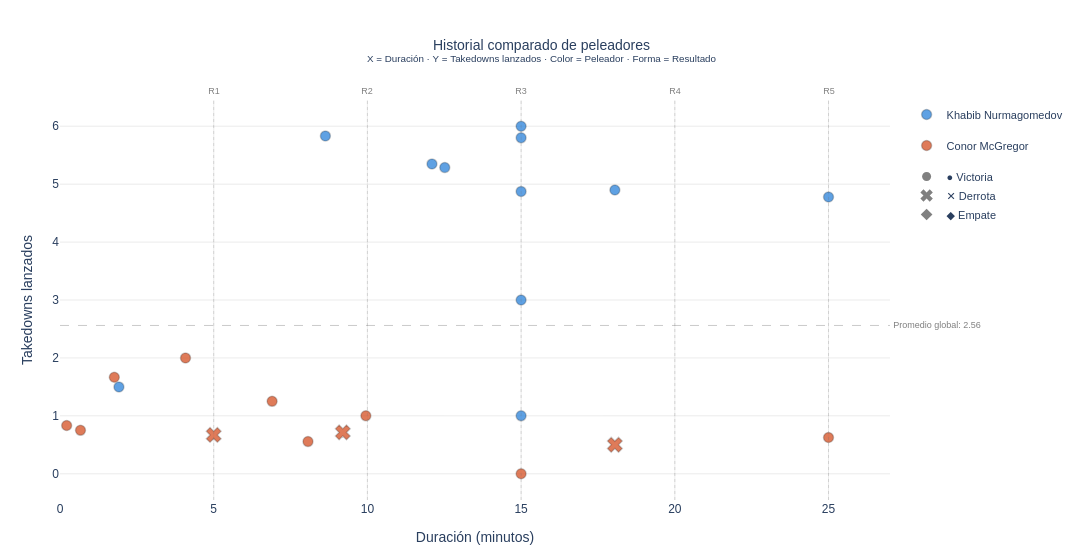

In [162]:
import plotly.graph_objects as go
import pandas as pd

# 1. Configuración
peleadores = ['Khabib Nurmagomedov', 'Conor McGregor']
metrica    = 'td_landed'  # opciones: 'sig_str', 'td_landed', 'sig_str_pct', 'sub_att'

metrica_config = {
    'sig_str' : {'col': 'sig_str',   'label': 'Sig. Strikes por minuto'},
    'td_landed'  : {'col': 'td_landed',    'label': 'Takedowns lanzados'},
    'sig_str_pct': {'col': 'sig_str_pct',  'label': 'Precisión de strikes %'},
    'sub_att'    : {'col': 'sub_att',      'label': 'Intentos de sumisión'},
}

# color por peleador, forma por resultado
colores_peleador = {
    peleadores[0]: '#378ADD',
    peleadores[1]: '#D85A30',
    #peleadores[2]: '#1D9E75',
    #peleadores[3]: '#9B59B6',
}

symbol_map = {'Victoria': 'circle', 'Derrota': 'x', 'Empate': 'diamond'}
size_map   = {'Victoria': 10,       'Derrota': 13,  'Empate': 10}

# 2. Extraer historial
def get_historial_scatter(nombre, df_ufc):
    mask   = (df_ufc['R_fighter'] == nombre) | (df_ufc['B_fighter'] == nombre)
    peleas = df_ufc[mask].copy()

    registros = []
    for n_pelea, (_, row) in enumerate(peleas.iterrows(), start=1):
        winner = row['Winner']
        if winner == 'Draw':
            resultado = 'Empate'
        elif (winner == 'Red'  and row['R_fighter'] == nombre) or \
             (winner == 'Blue' and row['B_fighter'] == nombre):
            resultado = 'Victoria'
        else:
            resultado = 'Derrota'

        lado     = 'R' if row['R_fighter'] == nombre else 'B'
        dur_secs = row.get('total_fight_time_secs',        None)
        sig_str  = row.get(f'{lado}_avg_SIG_STR_landed',   None)
        sig_pct  = row.get(f'{lado}_avg_SIG_STR_pct',      None)
        td_land  = row.get(f'{lado}_avg_TD_landed',         None)
        sub_att  = row.get(f'{lado}_avg_SUB_ATT',           None)


        registros.append({
            'peleador'   : nombre,
            'n_pelea'    : n_pelea,
            'resultado'  : resultado,
            'dur_min'    : dur_secs / 60 if dur_secs else None,
            'sig_str' : sig_str,
            'sig_str_pct': sig_pct,
            'td_landed'  : td_land,
            'sub_att'    : sub_att,
            'finish'     : row.get('finish', 'N/A'),
            'oponente'   : row['B_fighter'] if lado == 'R' else row['R_fighter'],
            'fecha'      : row['date'].strftime('%Y-%m-%d') if pd.notna(row['date']) else 'N/A',
        })

    return pd.DataFrame(registros)

# 3. Construir df combinado
col_x    = metrica_config[metrica]['col']
label_x  = metrica_config[metrica]['label']

df_todos = pd.concat([
    get_historial_scatter(p, df_ufc) for p in peleadores
], ignore_index=True).dropna(subset=[col_x, 'dur_min'])

# 4. Figura — un trace por peleador × resultado
fig = go.Figure()

# ✅ Trazar en orden: primero victorias, luego empates, luego derrotas
# para que las derrotas (X) queden encima visualmente
orden_resultado = ['Victoria', 'Empate', 'Derrota']

for resultado in orden_resultado:
    for nombre in peleadores:
        grupo = df_todos[
            (df_todos['peleador']  == nombre) &
            (df_todos['resultado'] == resultado)
        ]

        if grupo.empty:
            continue

        color = colores_peleador[nombre]

        fig.add_trace(go.Scatter(
            x    = grupo['dur_min'],
            y    = grupo[col_x],
            mode = 'markers',
            # ✅ nombre en leyenda solo en primera aparición del peleador
            name            = nombre if resultado == 'Victoria' else None,
            legendgroup     = nombre,
            showlegend      = resultado == 'Victoria',
            marker = dict(
                color   = color,
                symbol  = symbol_map[resultado],
                size    = size_map[resultado],
                opacity = 0.80,
                line    = dict(
                    width = 1.5,
                    color = 'rgba(0,0,0,0.25)'
                ),
            ),
            customdata    = grupo[['oponente', 'fecha', 'finish', 'resultado', 'n_pelea']].values,
            hovertemplate = (
                f'<b>{nombre}</b> vs %{{customdata[0]}}<br>'
                'Fecha       : %{customdata[1]}<br>'
                'Resultado   : <b>%{customdata[3]}</b><br>'
                'Finalización: %{customdata[2]}<br>'
                f'{label_x}: ' + '%{y:.2f}<br>'
                'Duración    : %{x:.1f} min<br>'
                'Pelea #%{customdata[4]}'
                '<extra></extra>'
            ),
        ))

# 5. Líneas de rounds en eje X
for r in range(1, 6):
    fig.add_vline(
        x                   = r * 5,
        line_dash           = 'dot',
        line_color          = 'rgba(128,128,128,0.25)',
        line_width          = 1,
        annotation_text     = f'R{r}',
        annotation_position = 'top',
        annotation_font     = dict(size=9, color='gray'),
    )

# 6. Promedio global de la métrica
avg = df_todos[col_x].mean()
fig.add_hline(
    y                   = avg,
    line_dash           = 'dash',
    line_color          = 'rgba(128,128,128,0.4)',
    line_width          = 1,
    annotation_text     = f'Promedio global: {avg:.2f}',
    annotation_position = 'right',
    annotation_font     = dict(size=9, color='gray'),
)

# 7. Leyenda de formas — anotación manual
fig.add_trace(go.Scatter(
    x=[None], y=[None], mode='markers',
    marker=dict(symbol='circle', size=9, color='gray'),
    name='● Victoria', showlegend=True, legendgroup='shapes'
))
fig.add_trace(go.Scatter(
    x=[None], y=[None], mode='markers',
    marker=dict(symbol='x', size=11, color='gray'),
    name='✕ Derrota', showlegend=True, legendgroup='shapes'
))
fig.add_trace(go.Scatter(
    x=[None], y=[None], mode='markers',
    marker=dict(symbol='diamond', size=9, color='gray'),
    name='◆ Empate', showlegend=True, legendgroup='shapes'
))

# 8. Layout
fig.update_layout(
    title=dict(
        text=(
            'Historial comparado de peleadores'
            f'<br><sup>X = Duración · Y = {label_x} · Color = Peleador · Forma = Resultado</sup>'
        ),
        x    = 0.5,
        font = dict(size=14),
    ),
    xaxis=dict(
        title     = 'Duración (minutos)',
        gridcolor = 'rgba(128,128,128,0.15)',
        zeroline  = False,
        range     = [0, 27],
    ),
    yaxis=dict(
        title     = label_x,
        gridcolor = 'rgba(128,128,128,0.15)',
        zeroline  = False,
    ),
    legend=dict(
        orientation = 'v',
        yanchor     = 'top',
        y           = 1,
        xanchor     = 'left',
        x           = 1.02,
        font        = dict(size=11),
        tracegroupgap = 12,
    ),
    paper_bgcolor = 'rgba(0,0,0,0)',
    plot_bgcolor  = 'rgba(0,0,0,0)',
    height        = 560,
    margin        = dict(t=100, b=60, l=60, r=160),
)

fig.show()

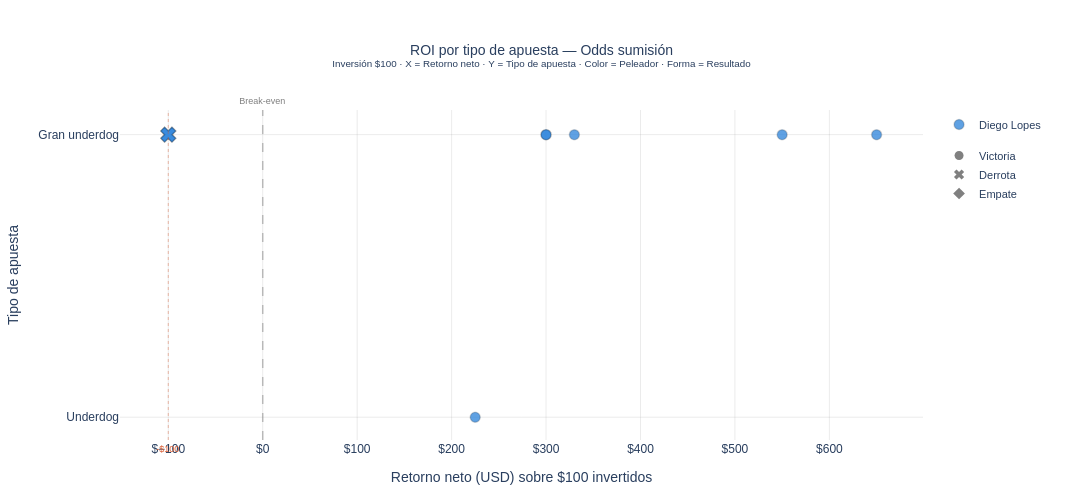

In [163]:
import plotly.graph_objects as go
import pandas as pd
import numpy as np

# 1. Configuración
peleadores = ['Diego Lopes']
inversion  = 100

# ✅ Selector de tipo de odds
tipo_odds = 'sub_odds'  # opciones: 'R_odds', 'r_dec_odds', 'r_sub_odds', 'r_ko_odds'

odds_config = {
    'odds'    : {'col_r': 'R_odds',     'col_b': 'B_odds',     'label': 'Odds generales'},
    'dec_odds': {'col_r': 'r_dec_odds', 'col_b': 'b_dec_odds', 'label': 'Odds decisión'},
    'sub_odds': {'col_r': 'r_sub_odds', 'col_b': 'b_sub_odds', 'label': 'Odds sumisión'},
    'ko_odds' : {'col_r': 'r_ko_odds',  'col_b': 'b_ko_odds',  'label': 'Odds KO/TKO'},
}

col_r  = odds_config[tipo_odds]['col_r']
col_b  = odds_config[tipo_odds]['col_b']
label  = odds_config[tipo_odds]['label']

colores_peleador = {
    peleadores[0]: '#378ADD',
    #peleadores[1]: '#D85A30',
    #peleadores[2]: '#1D9E75',
    #peleadores[3]: '#9B59B6',
}

symbol_map = {'Victoria': 'circle', 'Derrota': 'x',  'Empate': 'diamond'}
size_map   = {'Victoria': 10,       'Derrota': 13,    'Empate': 10}

orden_tipo = ['Gran favorito', 'Favorito', "Pick'em", 'Underdog', 'Gran underdog']
color_tipo = {
    'Gran favorito' : '#1D9E75',
    'Favorito'      : '#378ADD',
    "Pick'em"       : '#888780',
    'Underdog'      : '#F39C12',
    'Gran underdog' : '#D85A30',
}

# 2. Funciones
def calcular_retorno(odds, inversion, gano):
    if not gano:
        return -inversion
    if pd.isna(odds):
        return None
    if odds > 0:
        ganancia = inversion * (odds / 100)
    else:
        ganancia = inversion * (100 / abs(odds))
    return round(ganancia, 2)

def get_tipo_apuesta(odds):
    if pd.isna(odds):
        return None
    elif odds < -200:
        return 'Gran favorito'
    elif odds < 0:
        return 'Favorito'
    elif odds < 150:
        return "Pick'em"
    elif odds < 300:
        return 'Underdog'
    else:
        return 'Gran underdog'

# 3. Extraer historial — ahora recibe col_r y col_b dinámicamente
def get_historial_apuestas(nombre, df_ufc, inversion, col_r, col_b):
    mask   = (df_ufc['R_fighter'] == nombre) | (df_ufc['B_fighter'] == nombre)
    peleas = df_ufc[mask].copy()

    registros = []
    for n_pelea, (_, row) in enumerate(peleas.iterrows(), start=1):
        lado = 'R' if row['R_fighter'] == nombre else 'B'

        winner = row['Winner']
        if winner == 'Draw':
            resultado = 'Empate'
            gano      = False
        elif (winner == 'Red'  and lado == 'R') or \
             (winner == 'Blue' and lado == 'B'):
            resultado = 'Victoria'
            gano      = True
        else:
            resultado = 'Derrota'
            gano      = False

        # ✅ Seleccionar columna correcta según lado y tipo de odds elegido
        odds    = row.get(col_r if lado == 'R' else col_b, None)
        retorno = calcular_retorno(odds, inversion, gano)
        tipo    = get_tipo_apuesta(odds)
        oponente= row['B_fighter'] if lado == 'R' else row['R_fighter']
        fecha   = row['date'].strftime('%Y-%m-%d') if pd.notna(row['date']) else 'N/A'

        registros.append({
            'peleador' : nombre,
            'n_pelea'  : n_pelea,
            'resultado': resultado,
            'odds'     : odds,
            'tipo'     : tipo,
            'retorno'  : retorno,
            'oponente' : oponente,
            'fecha'    : fecha,
            'finish'   : row.get('finish', 'N/A'),
        })

    return pd.DataFrame(registros)

# 4. Construir df combinado
df_todos = pd.concat([
    get_historial_apuestas(p, df_ufc, inversion, col_r, col_b)
    for p in peleadores
], ignore_index=True).dropna(subset=['retorno', 'tipo'])

df_todos['tipo'] = pd.Categorical(df_todos['tipo'], categories=orden_tipo, ordered=True)

# 5. Figura
fig = go.Figure()

for resultado in ['Victoria', 'Empate', 'Derrota']:
    for nombre in peleadores:
        grupo = df_todos[
            (df_todos['peleador']  == nombre) &
            (df_todos['resultado'] == resultado)
        ]
        if grupo.empty:
            continue

        fig.add_trace(go.Scatter(
            x    = grupo['retorno'],
            y    = grupo['tipo'],
            mode = 'markers',
            name            = nombre if resultado == 'Victoria' else None,
            legendgroup     = nombre,
            showlegend      = resultado == 'Victoria',
            marker = dict(
                color   = colores_peleador[nombre],
                symbol  = symbol_map[resultado],
                size    = size_map[resultado],
                opacity = 0.80,
                line    = dict(width=1.5, color='rgba(0,0,0,0.2)'),
            ),
            customdata    = grupo[['oponente', 'fecha', 'finish', 'resultado', 'odds', 'n_pelea']].values,
            hovertemplate = (
                f'<b>{nombre}</b> vs %{{customdata[0]}}<br>'
                'Fecha         : %{customdata[1]}<br>'
                'Resultado     : <b>%{customdata[3]}</b><br>'
                'Finalización  : %{customdata[2]}<br>'
                f'Odds ({label}): %{{customdata[4]}}<br>'
                'Retorno neto  : $%{x:.2f}<br>'
                'Pelea #%{customdata[5]}'
                '<extra></extra>'
            ),
        ))

# 6. Referencias
fig.add_vline(
    x=0, line_dash='dash', line_color='rgba(128,128,128,0.5)', line_width=1.5,
    annotation_text='Break-even', annotation_position='top',
    annotation_font=dict(size=9, color='gray'),
)
fig.add_vline(
    x=-inversion, line_dash='dot', line_color='rgba(216,90,48,0.4)', line_width=1,
    annotation_text=f'-${inversion}', annotation_position='bottom',
    annotation_font=dict(size=9, color='#D85A30'),
)

# 7. Leyenda de formas
for sym, lbl in [('circle','Victoria'), ('x','Derrota'), ('diamond','Empate')]:
    fig.add_trace(go.Scatter(
        x=[None], y=[None], mode='markers',
        marker=dict(symbol=sym, size=9, color='gray'),
        name=lbl, showlegend=True, legendgroup='shapes'
    ))

# 8. Layout
fig.update_layout(
    title=dict(
        text=(
            f'ROI por tipo de apuesta — {label}<br>'
            f'<sup>Inversión ${inversion} · X = Retorno neto · Y = Tipo de apuesta · Color = Peleador · Forma = Resultado</sup>'
        ),
        x=0.5, font=dict(size=14),
    ),
    xaxis=dict(
        title     = f'Retorno neto (USD) sobre ${inversion} invertidos',
        gridcolor = 'rgba(128,128,128,0.15)',
        zeroline  = False,
        tickprefix= '$',
    ),
    yaxis=dict(
        title         = 'Tipo de apuesta',
        gridcolor     = 'rgba(128,128,128,0.15)',
        categoryorder = 'array',
        categoryarray = orden_tipo,
    ),
    legend=dict(
        orientation='v', yanchor='top', y=1,
        xanchor='left', x=1.02,
        font=dict(size=11), tracegroupgap=12,
    ),
    paper_bgcolor='rgba(0,0,0,0)',
    plot_bgcolor ='rgba(0,0,0,0)',
    height=500,
    margin=dict(t=110, b=60, l=120, r=160),
)

fig.show()

In [164]:
print([c for c in df_ufc.columns if 'weight' in c.lower() or 'class' in c.lower() or 'divis' in c.lower()])
print(df_ufc.iloc[0][['R_fighter', 'B_fighter', 'date']])

['weight_class', 'B_Weight_lbs', 'R_Weight_lbs', 'B_match_weightclass_rank', 'R_match_weightclass_rank', "R_Women's Flyweight_rank", "R_Women's Featherweight_rank", "R_Women's Strawweight_rank", "R_Women's Bantamweight_rank", 'R_Heavyweight_rank', 'R_Light Heavyweight_rank', 'R_Middleweight_rank', 'R_Welterweight_rank', 'R_Lightweight_rank', 'R_Featherweight_rank', 'R_Bantamweight_rank', 'R_Flyweight_rank', "B_Women's Flyweight_rank", "B_Women's Featherweight_rank", "B_Women's Strawweight_rank", "B_Women's Bantamweight_rank", 'B_Heavyweight_rank', 'B_Light Heavyweight_rank', 'B_Middleweight_rank', 'B_Welterweight_rank', 'B_Lightweight_rank', 'B_Featherweight_rank', 'B_Bantamweight_rank', 'B_Flyweight_rank']
R_fighter           Eric Schafer
B_fighter            Jason Brilz
date         2010-03-21 00:00:00
Name: 0, dtype: object


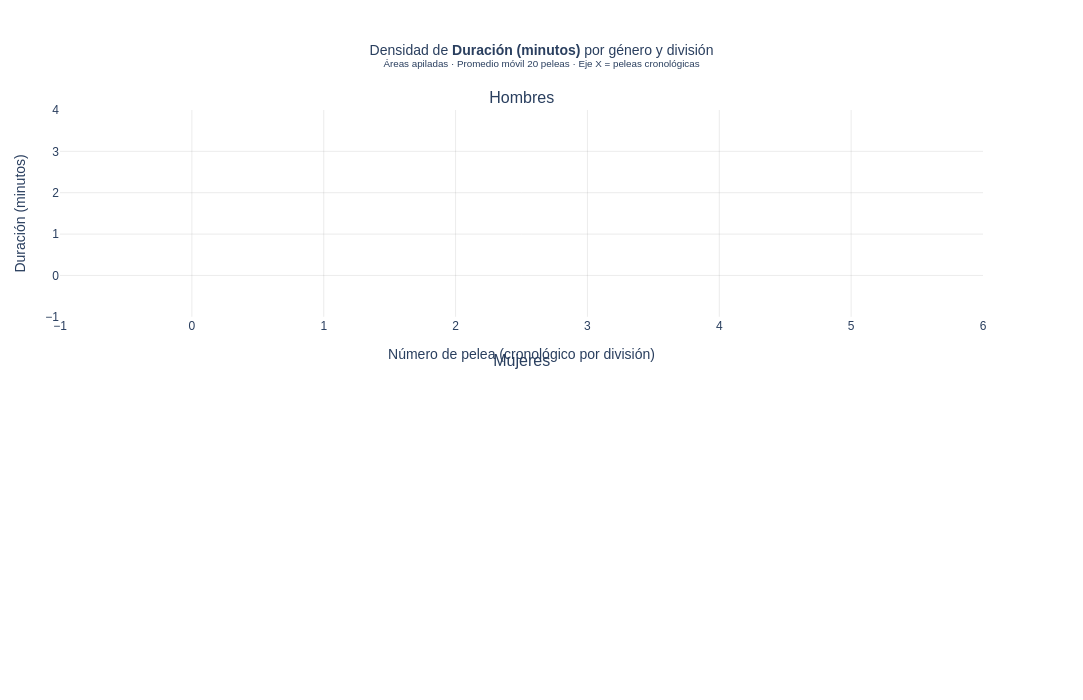

In [165]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd
import numpy as np

# 1. Configuración
col_division = 'weight_class'
col_genero   = 'gender'
ventana      = 20

# ✅ Selector
metrica = 'dur_min'  # opciones abajo

metrica_config = {
    'dur_min'    : {'col': 'dur_min',     'label': 'Duración (minutos)'},
    'sig_str_r'  : {'col': 'sig_str_r',   'label': 'Sig. Strikes lanzados (Red)'},
    'sig_pct_r'  : {'col': 'sig_pct_r',   'label': 'Precisión strikes (Red)'},
    'td_land_r'  : {'col': 'td_land_r',   'label': 'Takedowns lanzados (Red)'},
    'sub_att_r'  : {'col': 'sub_att_r',   'label': 'Intentos sumisión (Red)'},
}

col_sel   = metrica_config[metrica]['col']
label_sel = metrica_config[metrica]['label']

# 2. Preparar datos — extraer todas las métricas de una vez
df_plot = df_ufc[[
    col_division, col_genero, 'date',
    'total_fight_time_secs',
    'R_avg_SIG_STR_landed', 'R_avg_SIG_STR_pct',
    'R_avg_TD_landed', 'R_avg_SUB_ATT',
]].copy()

df_plot = df_plot.dropna(subset=[col_division, col_genero])
df_plot['dur_min']   = df_plot['total_fight_time_secs'] / 60
df_plot['sig_str_r'] = df_plot['R_avg_SIG_STR_landed']
df_plot['sig_pct_r'] = df_plot['R_avg_SIG_STR_pct']
df_plot['td_land_r'] = df_plot['R_avg_TD_landed']
df_plot['sub_att_r'] = df_plot['R_avg_SUB_ATT']
df_plot = df_plot.sort_values('date').reset_index(drop=True)

# 3. Divisiones
divisiones_hombre = [
    'Heavyweight', 'Light Heavyweight', 'Middleweight',
    'Welterweight', 'Lightweight', 'Featherweight',
    'Bantamweight', 'Flyweight',
]
divisiones_mujer = [
    "Women's Strawweight", "Women's Flyweight",
    "Women's Bantamweight", "Women's Featherweight",
]

colores_div = {
    'Heavyweight'          : '#2C2C2A',
    'Light Heavyweight'    : '#5F5E5A',
    'Middleweight'         : '#D85A30',
    'Welterweight'         : '#378ADD',
    'Lightweight'          : '#1D9E75',
    'Featherweight'        : '#9B59B6',
    'Bantamweight'         : '#F39C12',
    'Flyweight'            : '#E24B4A',
    "Women's Strawweight"  : '#E24B4A',
    "Women's Flyweight"    : '#F39C12',
    "Women's Bantamweight" : '#9B59B6',
    "Women's Featherweight": '#1D9E75',
}

# 4. Función de traces
def build_traces(df, divisiones, col_division, col_sel, ventana, stack_id, show_legend):
    traces = []
    for div in divisiones:
        grupo = df[df[col_division] == div].copy()
        if grupo.empty:
            continue

        grupo = grupo.dropna(subset=[col_sel])
        grupo = grupo.sort_values('date').reset_index(drop=True)
        grupo['n_pelea']    = grupo.index + 1
        grupo['val_smooth'] = grupo[col_sel].rolling(
            window=ventana, min_periods=5
        ).mean()
        grupo = grupo.dropna(subset=['val_smooth'])

        if grupo.empty:
            continue

        color = colores_div.get(div, '#888780')

        traces.append(go.Scatter(
            x             = grupo['n_pelea'],
            y             = grupo['val_smooth'],
            name          = div,
            mode          = 'lines',
            line          = dict(width=0.5, color=color),
            fill          = 'tonexty',
            fillcolor     = color + '55',
            stackgroup    = stack_id,
            legendgroup   = div,
            showlegend    = show_legend,
            hovertemplate = (
                f'<b>{div}</b><br>'
                'Pelea #%{x}<br>'
                f'{label_sel}: ' + '%{y:.2f}'
                '<extra></extra>'
            ),
        ))
    return traces

# 5. Subplots
fig = make_subplots(
    rows=2, cols=1,
    subplot_titles=['Hombres', 'Mujeres'],
    vertical_spacing=0.12,
)

config_generos = [
    {'label': 'Male',   'divisiones': divisiones_hombre, 'row': 1, 'stack': 'stack_1', 'legend': True},
    {'label': 'Female', 'divisiones': divisiones_mujer,  'row': 2, 'stack': 'stack_2', 'legend': False},
]

for cfg in config_generos:
    df_gen = df_plot[df_plot[col_genero] == cfg['label']]
    traces = build_traces(
        df_gen, cfg['divisiones'], col_division,
        col_sel, ventana, cfg['stack'], cfg['legend']
    )
    for t in traces:
        fig.add_trace(t, row=cfg['row'], col=1)

# 6. Layout
fig.update_layout(
    title=dict(
        text=(
            f'Densidad de <b>{label_sel}</b> por género y división'
            f'<br><sup>Áreas apiladas · Promedio móvil {ventana} peleas · Eje X = peleas cronológicas</sup>'
        ),
        x=0.5, font=dict(size=14),
    ),
    legend=dict(
        orientation='h', yanchor='bottom', y=-0.15,
        xanchor='center', x=0.5,
        font=dict(size=10), tracegroupgap=8,
    ),
    hovermode     = 'x unified',
    paper_bgcolor = 'rgba(0,0,0,0)',
    plot_bgcolor  = 'rgba(0,0,0,0)',
    height        = 700,
    margin        = dict(t=110, b=120, l=60, r=100),
)
fig.update_xaxes(
    title_text='Número de pelea (cronológico por división)',
    gridcolor='rgba(128,128,128,0.15)', zeroline=False,
)
fig.update_yaxes(
    title_text=label_sel,
    gridcolor='rgba(128,128,128,0.15)', zeroline=False,
)

fig.show()

In [166]:
import plotly.graph_objects as go
import plotly.figure_factory as ff
import pandas as pd
import numpy as np

# 1. Selector
tipo_odds = 'R_odds'  # opciones: 'R_odds', 'r_dec_odds', 'r_sub_odds', 'r_ko_odds'

odds_config = {
    'R_odds'    : 'Odds generales',
    'r_dec_odds': 'Odds decisión',
    'r_sub_odds': 'Odds sumisión',
    'r_ko_odds' : 'Odds KO/TKO',
}
label_odds = odds_config[tipo_odds]

# 2. Atributos a correlacionar
atributos = {
    'R_avg_SIG_STR_landed' : 'Sig. Strikes lanzados',
    'R_avg_SIG_STR_pct'    : 'Precisión strikes',
    'R_avg_TD_landed'      : 'Takedowns lanzados',
    'R_avg_TD_pct'         : 'Precisión TD',
    'R_avg_SUB_ATT'        : 'Intentos sumisión',
    'R_Height_cms'         : 'Altura (cm)',
    'R_Reach_cms'          : 'Alcance (cm)',
    'R_age'                : 'Edad',
    'R_current_win_streak' : 'Racha victorias',
    'R_current_lose_streak': 'Racha derrotas',
}

# 3. Construir df de correlación
cols_needed = [tipo_odds] + list(atributos.keys())
df_corr = df_ufc[cols_needed].copy().dropna()

# Calcular correlaciones contra las odds
correlaciones = df_corr.corr()[tipo_odds].drop(tipo_odds)
correlaciones.index = [atributos[c] for c in correlaciones.index]
correlaciones = correlaciones.sort_values()

# 4. Colores por dirección y fuerza
def get_color(val):
    if val >= 0.3:   return '#1D9E75'
    elif val >= 0.1: return '#1D9E75AA'
    elif val >= 0:   return '#1D9E7555'
    elif val >= -0.1:return '#D85A3055'
    elif val >= -0.3:return '#D85A30AA'
    else:            return '#D85A30'

colores = [get_color(v) for v in correlaciones.values]

# 5. Figura principal — barras horizontales de correlación
fig = go.Figure()

fig.add_trace(go.Bar(
    x             = correlaciones.values,
    y             = correlaciones.index,
    orientation   = 'h',
    marker=dict(
        color = colores,
        line  = dict(width=0.5, color='rgba(0,0,0,0.2)'),
    ),
    customdata    = correlaciones.values,
    hovertemplate = (
        '<b>%{y}</b><br>'
        f'Correlación con {label_odds}: ' + '%{x:.3f}'
        '<extra></extra>'
    ),
))

# Línea de cero
fig.add_vline(x=0, line_color='rgba(128,128,128,0.5)', line_width=1)

# Zonas de referencia
for x0, x1, label, color in [
    (-1.0, -0.3, 'Correlación<br>fuerte negativa', 'rgba(216,90,48,0.06)'),
    (-0.3, -0.1, 'Moderada<br>negativa',           'rgba(216,90,48,0.03)'),
    ( 0.1,  0.3, 'Moderada<br>positiva',           'rgba(29,158,117,0.03)'),
    ( 0.3,  1.0, 'Correlación<br>fuerte positiva', 'rgba(29,158,117,0.06)'),
]:
    fig.add_vrect(
        x0=x0, x1=x1,
        fillcolor=color, line_width=0,
        annotation_text=label,
        annotation_position='top',
        annotation_font=dict(size=8, color='gray'),
    )

fig.update_layout(
    title=dict(
        text=(
            f'Correlación entre atributos y {label_odds}'
            '<br><sup>Positivo = odds más altas (underdog) · Negativo = odds más bajas (favorito)</sup>'
        ),
        x=0.5, font=dict(size=14),
    ),
    xaxis=dict(
        title     = 'Coeficiente de correlación de Pearson',
        gridcolor = 'rgba(128,128,128,0.15)',
        zeroline  = False,
        range     = [-1, 1],
        tickvals  = [-1, -0.5, -0.3, -0.1, 0, 0.1, 0.3, 0.5, 1],
    ),
    yaxis=dict(
        gridcolor = 'rgba(128,128,128,0.15)',
        zeroline  = False,
    ),
    paper_bgcolor = 'rgba(0,0,0,0)',
    plot_bgcolor  = 'rgba(0,0,0,0)',
    height        = 500,
    margin        = dict(t=110, b=60, l=160, r=60),
)

fig.show()

ValueError: 
    Invalid element(s) received for the 'color' property of bar.marker
        Invalid elements include: ['#D85A30AA', '#D85A30AA', '#D85A30AA', '#D85A3055', '#D85A3055', '#D85A3055', '#D85A3055', '#1D9E7555', '#1D9E75AA', '#1D9E75AA']

    The 'color' property is a color and may be specified as:
      - A hex string (e.g. '#ff0000')
      - An rgb/rgba string (e.g. 'rgb(255,0,0)')
      - An hsl/hsla string (e.g. 'hsl(0,100%,50%)')
      - An hsv/hsva string (e.g. 'hsv(0,100%,100%)')
      - A named CSS color: see https://plotly.com/python/css-colors/ for a list
      - A number that will be interpreted as a color
        according to bar.marker.colorscale
      - A list or array of any of the above

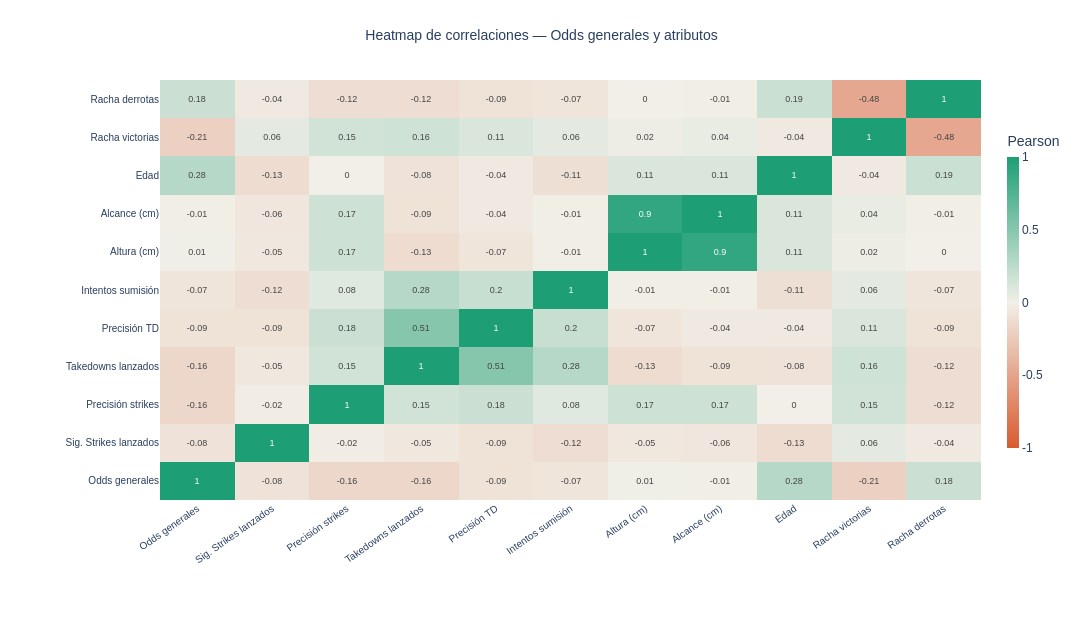

In [173]:
# BONUS — Heatmap completo atributos × atributos + odds
cols_heatmap = [tipo_odds] + list(atributos.keys())
df_heat      = df_ufc[cols_heatmap].dropna()

matriz = df_heat.corr().round(2)
labels = [label_odds] + list(atributos.values())
matriz.index   = labels
matriz.columns = labels

fig2 = go.Figure(go.Heatmap(
    z             = matriz.values,
    x             = labels,
    y             = labels,
    colorscale    = [
        [0.0, '#D85A30'], [0.5, '#F1EFE8'], [1.0, '#1D9E75']
    ],
    zmid          = 0,
    zmin          = -1,
    zmax          = 1,
    text          = matriz.values.round(2),
    texttemplate  = '%{text}',
    textfont      = dict(size=9),
    hovertemplate = '<b>%{y}</b> × <b>%{x}</b><br>Correlación: %{z:.3f}<extra></extra>',
    colorbar      = dict(
        title      = 'Pearson',
        tickvals   = [-1, -0.5, 0, 0.5, 1],
        ticktext   = ['-1', '-0.5', '0', '0.5', '1'],
        thickness  = 12,
        len        = 0.8,
    ),
))

fig2.update_layout(
    title=dict(
        text=f'Heatmap de correlaciones — {label_odds} y atributos',
        x=0.5, font=dict(size=14),
    ),
    paper_bgcolor = 'rgba(0,0,0,0)',
    plot_bgcolor  = 'rgba(0,0,0,0)',
    height        = 620,
    margin        = dict(t=80, b=120, l=160, r=60),
    xaxis         = dict(tickangle=-35, tickfont=dict(size=10)),
    yaxis         = dict(tickfont=dict(size=10)),
)

fig2.show()